# 🏦 Bank Loan Default Prediction — Exploratory Data Analysis (EDA)

## **Project Overview**
The goal of this project is to build a system that predicts whether a loan applicant is likely to default. This notebook focuses on **Exploratory Data Analysis (EDA)** to understand the dataset, uncover patterns, and prepare for feature engineering and modeling.

---

## **Dataset**
**Source:** Bank Loan Default Prediction Dataset
**Location:** `data/raw/`

**Description:**
The dataset contains applicant information, financial metrics, and loan-related attributes. Key columns may include:

- `age` — Age of the applicant
- `income` — Annual income
- `loan_amount` — Requested loan amount
- `employment_status` — Employment type/status
- `credit_score` — Credit score of the applicant
- `default` — Target variable (0 = no default, 1 = default)

> Note: Column names may vary slightly depending on the dataset version.

---

## **Objectives of EDA**
1. **Understand the dataset structure**
   - Inspect column types, missing values, and basic statistics.
2. **Explore target variable**
   - Analyze the distribution of defaults vs. non-defaults.
3. **Investigate features**
   - Examine distributions of numeric variables (`income`, `loan_amount`, `age`).
   - Explore categorical variables (`employment_status`, `loan_purpose`) and their impact on defaults.
4. **Identify data quality issues**
   - Missing values, outliers, inconsistent data.
5. **Uncover patterns**
   - Relationships between features and target variable.
6. **Provide actionable insights**
   - Highlight which factors may influence loan default risk.
7. **Prepare for next steps**
   - Define preprocessing and feature engineering strategies.

---

## **Notebook Structure**
1. **Data Loading & Inspection** — `.head()`, `.info()`, `.describe()`
2. **Missing Value Analysis** — Identify gaps and plan imputation
3. **Univariate Analysis** — Histograms, boxplots, countplots
4. **Bivariate Analysis** — Target vs features, correlation analysis
5. **Summary & Next Steps** — Insights and preprocessing plan

## New scale for PAY_0 to PAY_6

-2: No consumption; -1: Paid in full; 0: The use of revolving credit; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

[link to the forum](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608)

### Evaluation Metrics

Given the class imbalance in the target variable and the business objective of minimizing financial risk, evaluation metrics beyond accuracy are prioritized.

- **Recall** is the most critical metric, as it measures the model’s ability to correctly identify defaulters. Missing a defaulter (false negative) can lead to significant financial loss for the bank.

- **Precision** is also considered, as incorrectly classifying a reliable customer as a defaulter (false positive) may result in lost business opportunities.

- **F1-score** is used to balance precision and recall, providing a single metric for model comparison.

- **ROC-AUC** is evaluated to assess the model’s overall ability to distinguish between defaulters and non-defaulters across different thresholds.

This approach ensures that the model aligns with real-world business priorities, where identifying high-risk customers is more important than maximizing overall accuracy.

In [71]:
# Importing Libraries
import numpy as mp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [16]:
# Loading dataset
df = pd.read_csv('../data/raw/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [17]:
df.shape

(30000, 25)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

* No null values
* All the features are stored in numerical form but are not actually numerical

In [19]:
# Dropping id column
df = df.drop('ID', axis=1)

In [20]:
df.duplicated().sum()

np.int64(35)

In [21]:
# Dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [22]:
df.shape

(29965, 24)

## Exploratory Data Analysis

### Univariate Analysis (Categorical & Binary Features)

In [23]:
# Dataframe with categorical variables and converting them to type 'categorical'
cat_cols_list = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default.payment.next.month']
cat_cols = df[cat_cols_list].copy()
cat_cols = cat_cols.astype('category')
cat_cols.describe().transpose()

,count,unique,top,freq
SEX,29965,2,2,18091
EDUCATION,29965,7,2,14019
MARRIAGE,29965,4,2,15945
PAY_0,29965,11,0,14737
PAY_2,29965,11,0,15730
PAY_3,29965,11,0,15764
PAY_4,29965,11,0,16455
PAY_5,29965,10,0,16947
PAY_6,29965,10,0,16286
default.payment.next.month,29965,2,0,23335


* Need to check EDUCATION, MARRIAGE, PAY_0, PAY_2, PAY_3 and PAY_4. They have extra unique values.

In [24]:
for i in cat_cols_list:
    print(i)
    print(cat_cols[i].unique())

SEX
[2, 1]
Categories (2, int64): [1, 2]
EDUCATION
[2, 1, 3, 5, 4, 6, 0]
Categories (7, int64): [0, 1, 2, 3, 4, 5, 6]
MARRIAGE
[1, 2, 3, 0]
Categories (4, int64): [0, 1, 2, 3]
PAY_0
[2, -1, 0, -2, 1, ..., 4, 8, 7, 5, 6]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_2
[2, 0, -1, -2, 3, ..., 7, 4, 1, 6, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_3
[-1, 0, 2, -2, 3, ..., 6, 7, 1, 5, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_4
[-1, 0, -2, 2, 3, ..., 5, 7, 6, 1, 8]
Length: 11
Categories (11, int64): [-2, -1, 0, 1, ..., 5, 6, 7, 8]
PAY_5
[-2, 0, -1, 2, 3, 5, 4, 7, 8, 6]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
PAY_6
[-2, 2, 0, -1, 3, 6, 4, 7, 8, 5]
Categories (10, int64): [-2, -1, 0, 2, ..., 5, 6, 7, 8]
default.payment.next.month
[1, 0]
Categories (2, int64): [0, 1]


In [25]:
for i in cat_cols_list:
    print(cat_cols[i].value_counts().sort_index())

SEX
1    11874
2    18091
Name: count, dtype: int64
EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64
MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64
PAY_0
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64
PAY_2
-2     3752
-1     6046
 0    15730
 1       28
 2     3926
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64
PAY_3
-2     4055
-1     5934
 0    15764
 1        4
 2     3819
 3      240
 4       75
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64
PAY_4
-2     4318
-1     5683
 0    16455
 1        2
 2     3159
 3      180
 4       68
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64
PAY_5
-2     4516
-1     5535
 0    16947
 2     2626
 3      178
 4       83
 5       17
 6        

* Upon further investigation, I found a discussion forum that has info from the creator of the dataset. The discussion stated that the range for PAY_0 to PAY_6 is -2 to 9. Therefore, we can conclude that all the values for PAY_0 to PAY_6 are correct.
* Education (1 = graduate school; 2 = university; 3 = high school; 0, 4, 5, 6 = others). These are the true values of the education according to the author. We can merge 0, 4, 5 and 6 as they all represent 'other'.
* Marriage (1 = married; 2 = single; 3 = divorce; 0=others). These are the true values of Marriage according to the creator of the dataset. Therefore, all the values seem correct.

In [30]:
# Merging 0, 4, 5, and 6 in Education
cat_cols['EDUCATION'] = cat_cols['EDUCATION'].replace({4:0, 5:0, 6:0})
cat_cols['EDUCATION'].value_counts().sort_values()

EDUCATION
0      468
3     4915
1    10563
2    14019
Name: count, dtype: int64

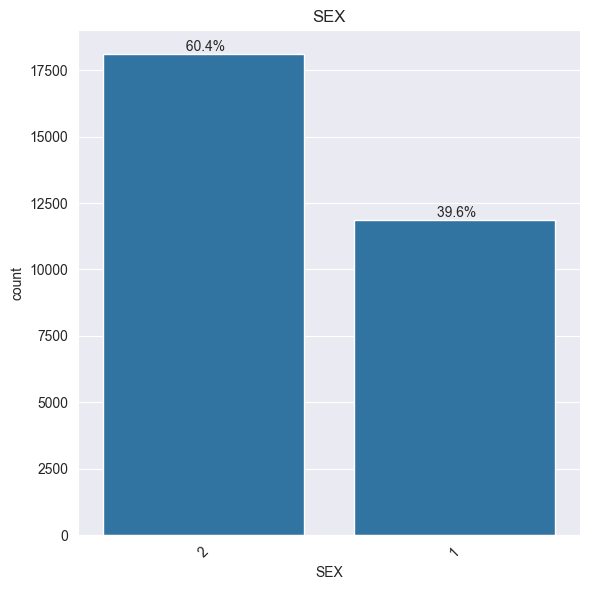

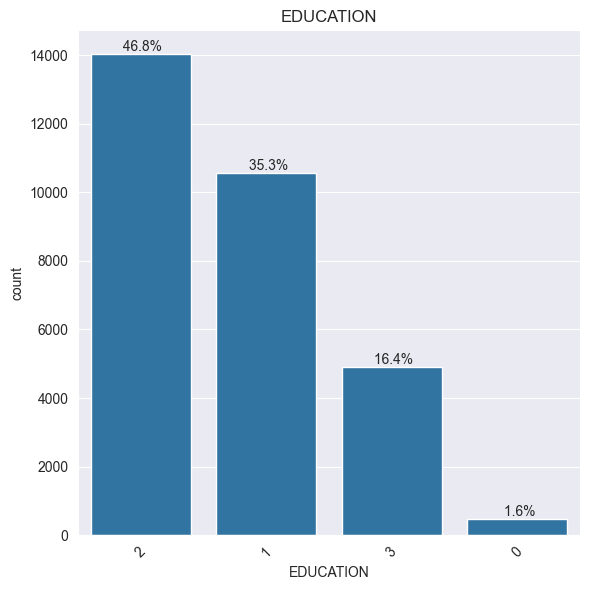

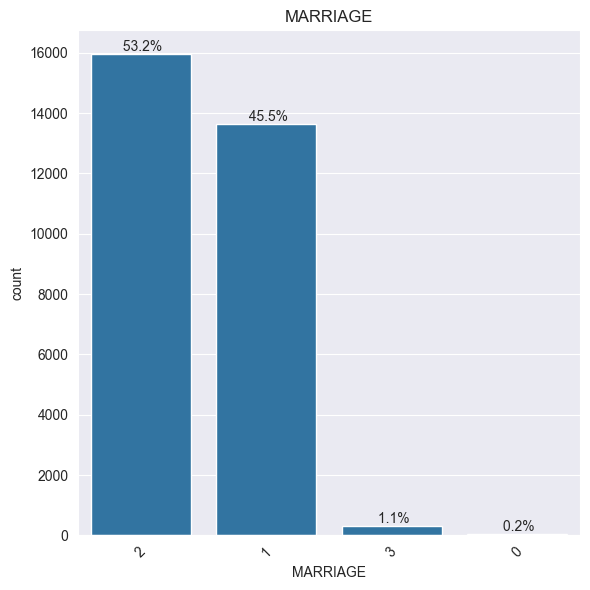

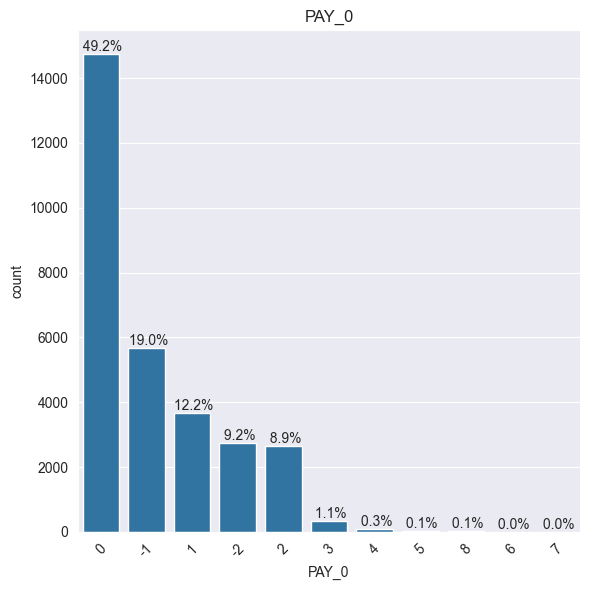

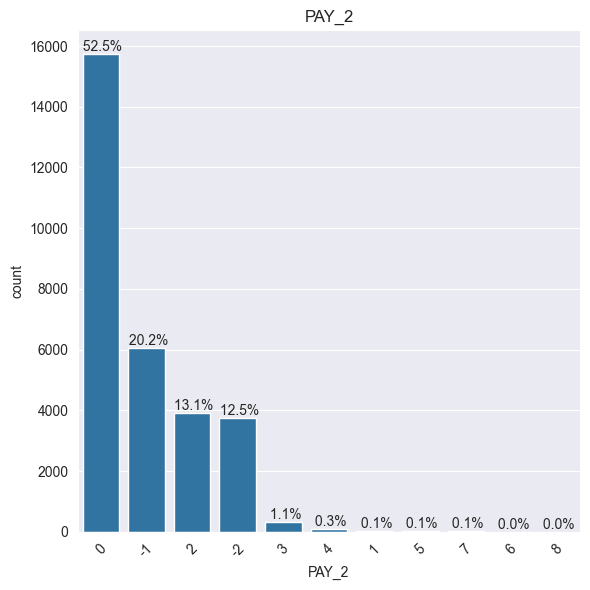

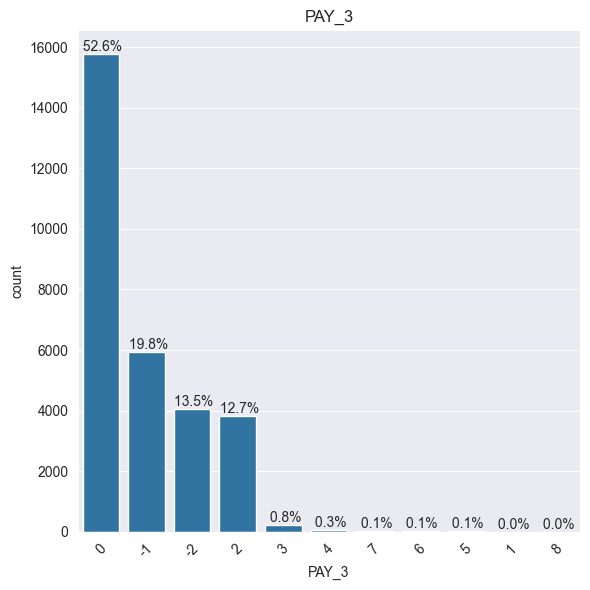

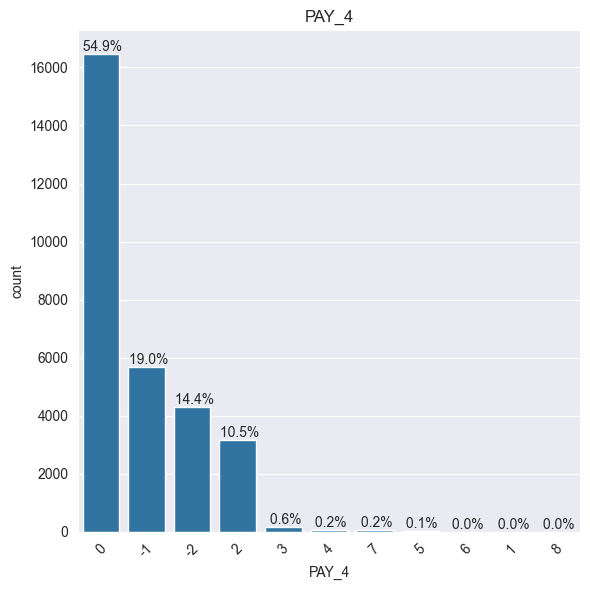

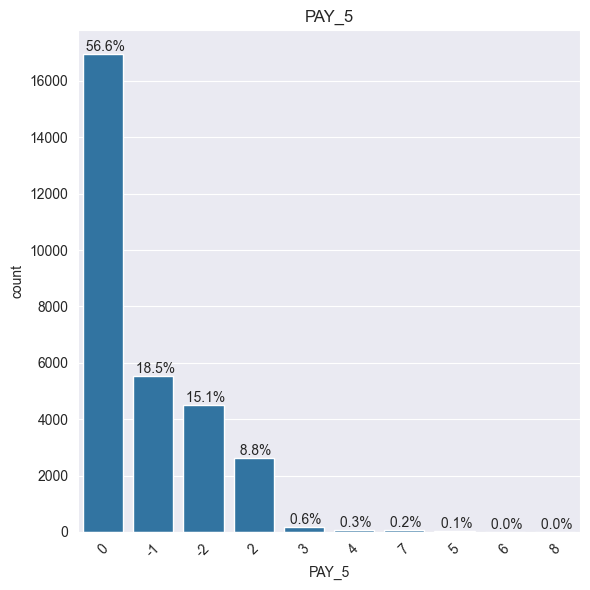

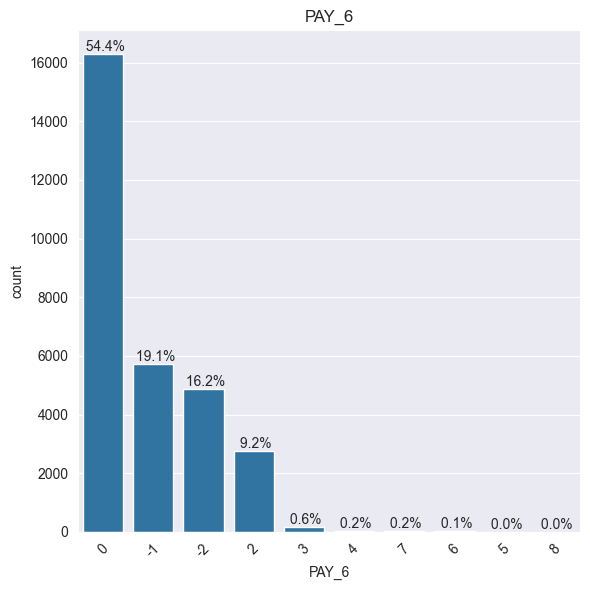

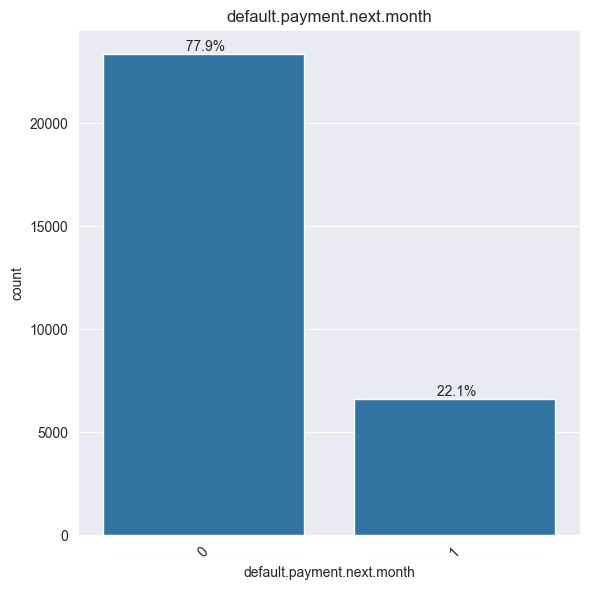

In [36]:
# Plotting countplots for the categorical variables
for i in cat_cols.columns:
    plt.figure(figsize=(6,6))

    ax = sns.countplot(x= cat_cols[i], order= cat_cols[i].value_counts().index)

    total = len(cat_cols[i].dropna())

    for j in ax.patches:
        percentage = 100 * j.get_height()/total
        ax.annotate(
            f'{percentage: .1f}%',
            (j.get_x() + j.get_width() / 2., j.get_height()),
            ha = 'center',
            va = 'bottom'
        )

    plt.title(f'{i}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### SEX
* The dataset has more females (2) at 60.4% than males (1) at 39.6%
* There is a noticeable class imbalance. We may have to be cautious of this if this turns out to be an important feature.

#### EDUCATION
* The dataset is dominated by university graduates (2) at 46.8% and graduate school (1) at 35.3%, meaning over 80% of clients are highly educated
* This suggests the bank's credit clients tend to be well-educated, which makes sense as educated individuals are more likely to qualify for credit

#### MARRIAGE
* The dataset is fairly balanced between single (2) at 53.2% and married (1) at 45.5% — together they make up nearly 99% of the data.
* Divorced (3) is only 1.1% and unknown (0) is just 0.2%

#### PAY_0 – PAY_6 (Repayment History)
* Class **0** appears to be the most frequent category, accounting for a significant proportion of the observations (in many cases close to 50%).
* Classes **-2, -1, and 2** also contain a substantial number of data points, indicating they are relatively well-represented in the dataset.
* The remaining classes (higher delay values) have very few observations, highlighting a potential issue of **class imbalance** within these features.
* One possible approach to address this imbalance is **binning**:
  * Combine classes **1 and 2** into a single group
  * Group all classes **≥ 3** into another category
* However, before applying such transformations, it is important to perform **bivariate analysis** to ensure that meaningful patterns or predictive signals are not lost.

#### default.payment.next.month
* This is the target variable. Class **0** accounts for 77.9% of the data while class **1** accounts for 22.1% of the data.
* This suggests serious imbalance in our target variable.
* Different strategies can be explored to deal with this:
    * Class Weights
    * SMOTE
    * Threshold Tuning

### Univariate Analysis (Numerical Features)

In [42]:
num_cols_list = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
num_cols =  df[num_cols_list].copy()
num_cols.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,29965.0,167442.005006,129760.135222,10000.0,50000.0,140000.0,240000.0,1000000.0
AGE,29965.0,35.487969,9.219459,21.0,28.0,34.0,41.0,79.0
BILL_AMT1,29965.0,51283.009778,73658.132403,-165580.0,3595.0,22438.0,67260.0,964511.0
BILL_AMT2,29965.0,49236.366294,71195.567392,-69777.0,3010.0,21295.0,64109.0,983931.0
BILL_AMT3,29965.0,47067.916069,69371.352323,-157264.0,2711.0,20135.0,60201.0,1664089.0
BILL_AMT4,29965.0,43313.329885,64353.514373,-170000.0,2360.0,19081.0,54601.0,891586.0
BILL_AMT5,29965.0,40358.334390,60817.130623,-81334.0,1787.0,18130.0,50247.0,927171.0
BILL_AMT6,29965.0,38917.012281,59574.147742,-339603.0,1262.0,17124.0,49252.0,961664.0
PAY_AMT1,29965.0,5670.099316,16571.849467,0.0,1000.0,2102.0,5008.0,873552.0
PAY_AMT2,29965.0,5927.983180,23053.456645,0.0,850.0,2010.0,5000.0,1684259.0


* All BILL_AMTs have negative values. These are still valid inputs as they can be overpayments, refunds or cashback credit.

In [44]:
# checking for percentage of negative values in BILL_ATMs
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i in bill_cols:
    neg_count = (df[i] < 0).sum()
    print(f'{i}: {neg_count} negative values ({100*neg_count/len(df):.1f}%)')

BILL_AMT1: 590 negative values (2.0%)
BILL_AMT2: 669 negative values (2.2%)
BILL_AMT3: 655 negative values (2.2%)
BILL_AMT4: 675 negative values (2.3%)
BILL_AMT5: 655 negative values (2.2%)
BILL_AMT6: 688 negative values (2.3%)


* Very small portion have overpayments, refunds or cashback credt. This seems like a real scenario.

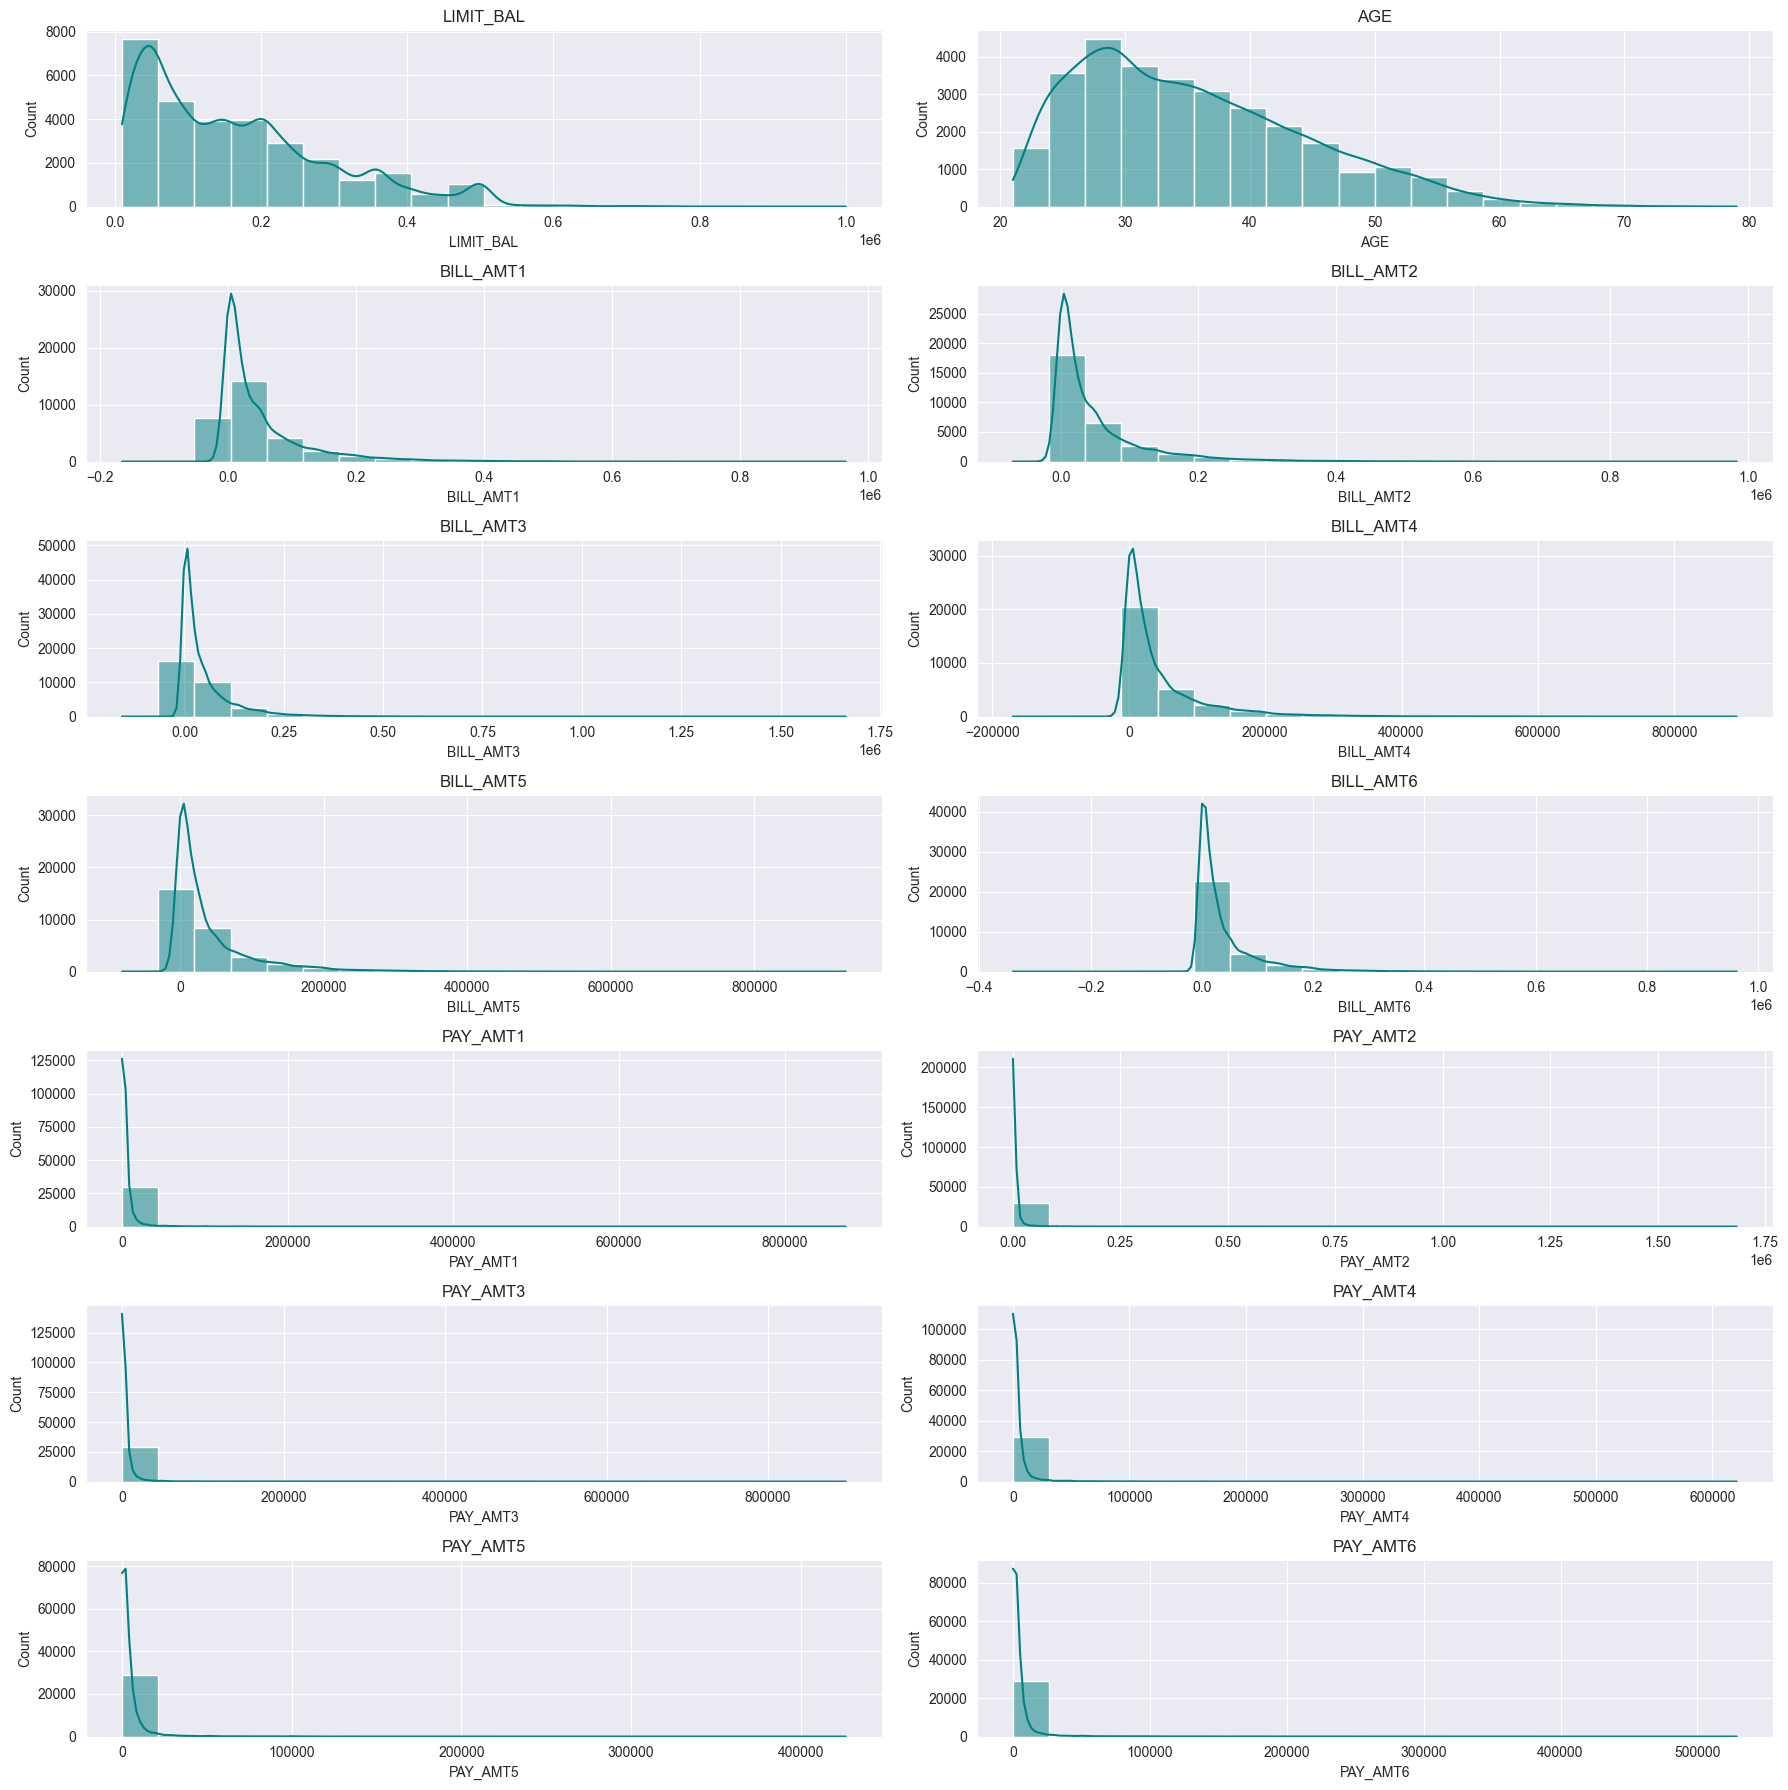

In [54]:
# Histograms for numerical features
plt.figure(figsize=(18,18))
for i, j in enumerate(num_cols_list,  1):
    plt.subplot(7,2,i)
    kde = True
    sns.histplot(num_cols[j], kde=True, color='teal', bins=20)
    plt.title(f'{j}')

plt.tight_layout()
plt.show()

#### LIMIT_BAL (Credit limit)
* Right skewed — most customers have lower credit limits, with a long tail of high-limit customers.
*  The bulk of customers have limits between 0–200,000 NT dollars.
* A small number of very high credit limits exist, suggesting a few wealthy/high-trust customers.

#### Age
* Right skewed but mildly — most customers are in their late 20s to mid 30s.
* Very few customers above 60, which makes sense for a credit card dataset.

#### BILL_AMT1–6
* All are heavily right skewed with a very sharp peak near zero.
* The majority of customers have low or near-zero bill amounts.
* Long tails extending to very high values indicate a small number of customers with very large bills.
* The distributions are very consistent across all 6 months, suggesting stable billing behaviour over time.

#### PAY_AMT1–6
* Extremely right skewed — the most skewed features in the dataset.
* The vast majority of customers make very small payments or zero payments.
* A tiny number of customers make very large payments, creating extremely long tails.
* The spike at zero is particularly notable — this likely represents customers who made no payment at all that month, which could an important signal for default prediction.

#### General Observation
* Skewness is a concern for all the numerical features. This needs to be handled with some kind of transformation.
* It also looks like there are a lot of outliers in all of the features.

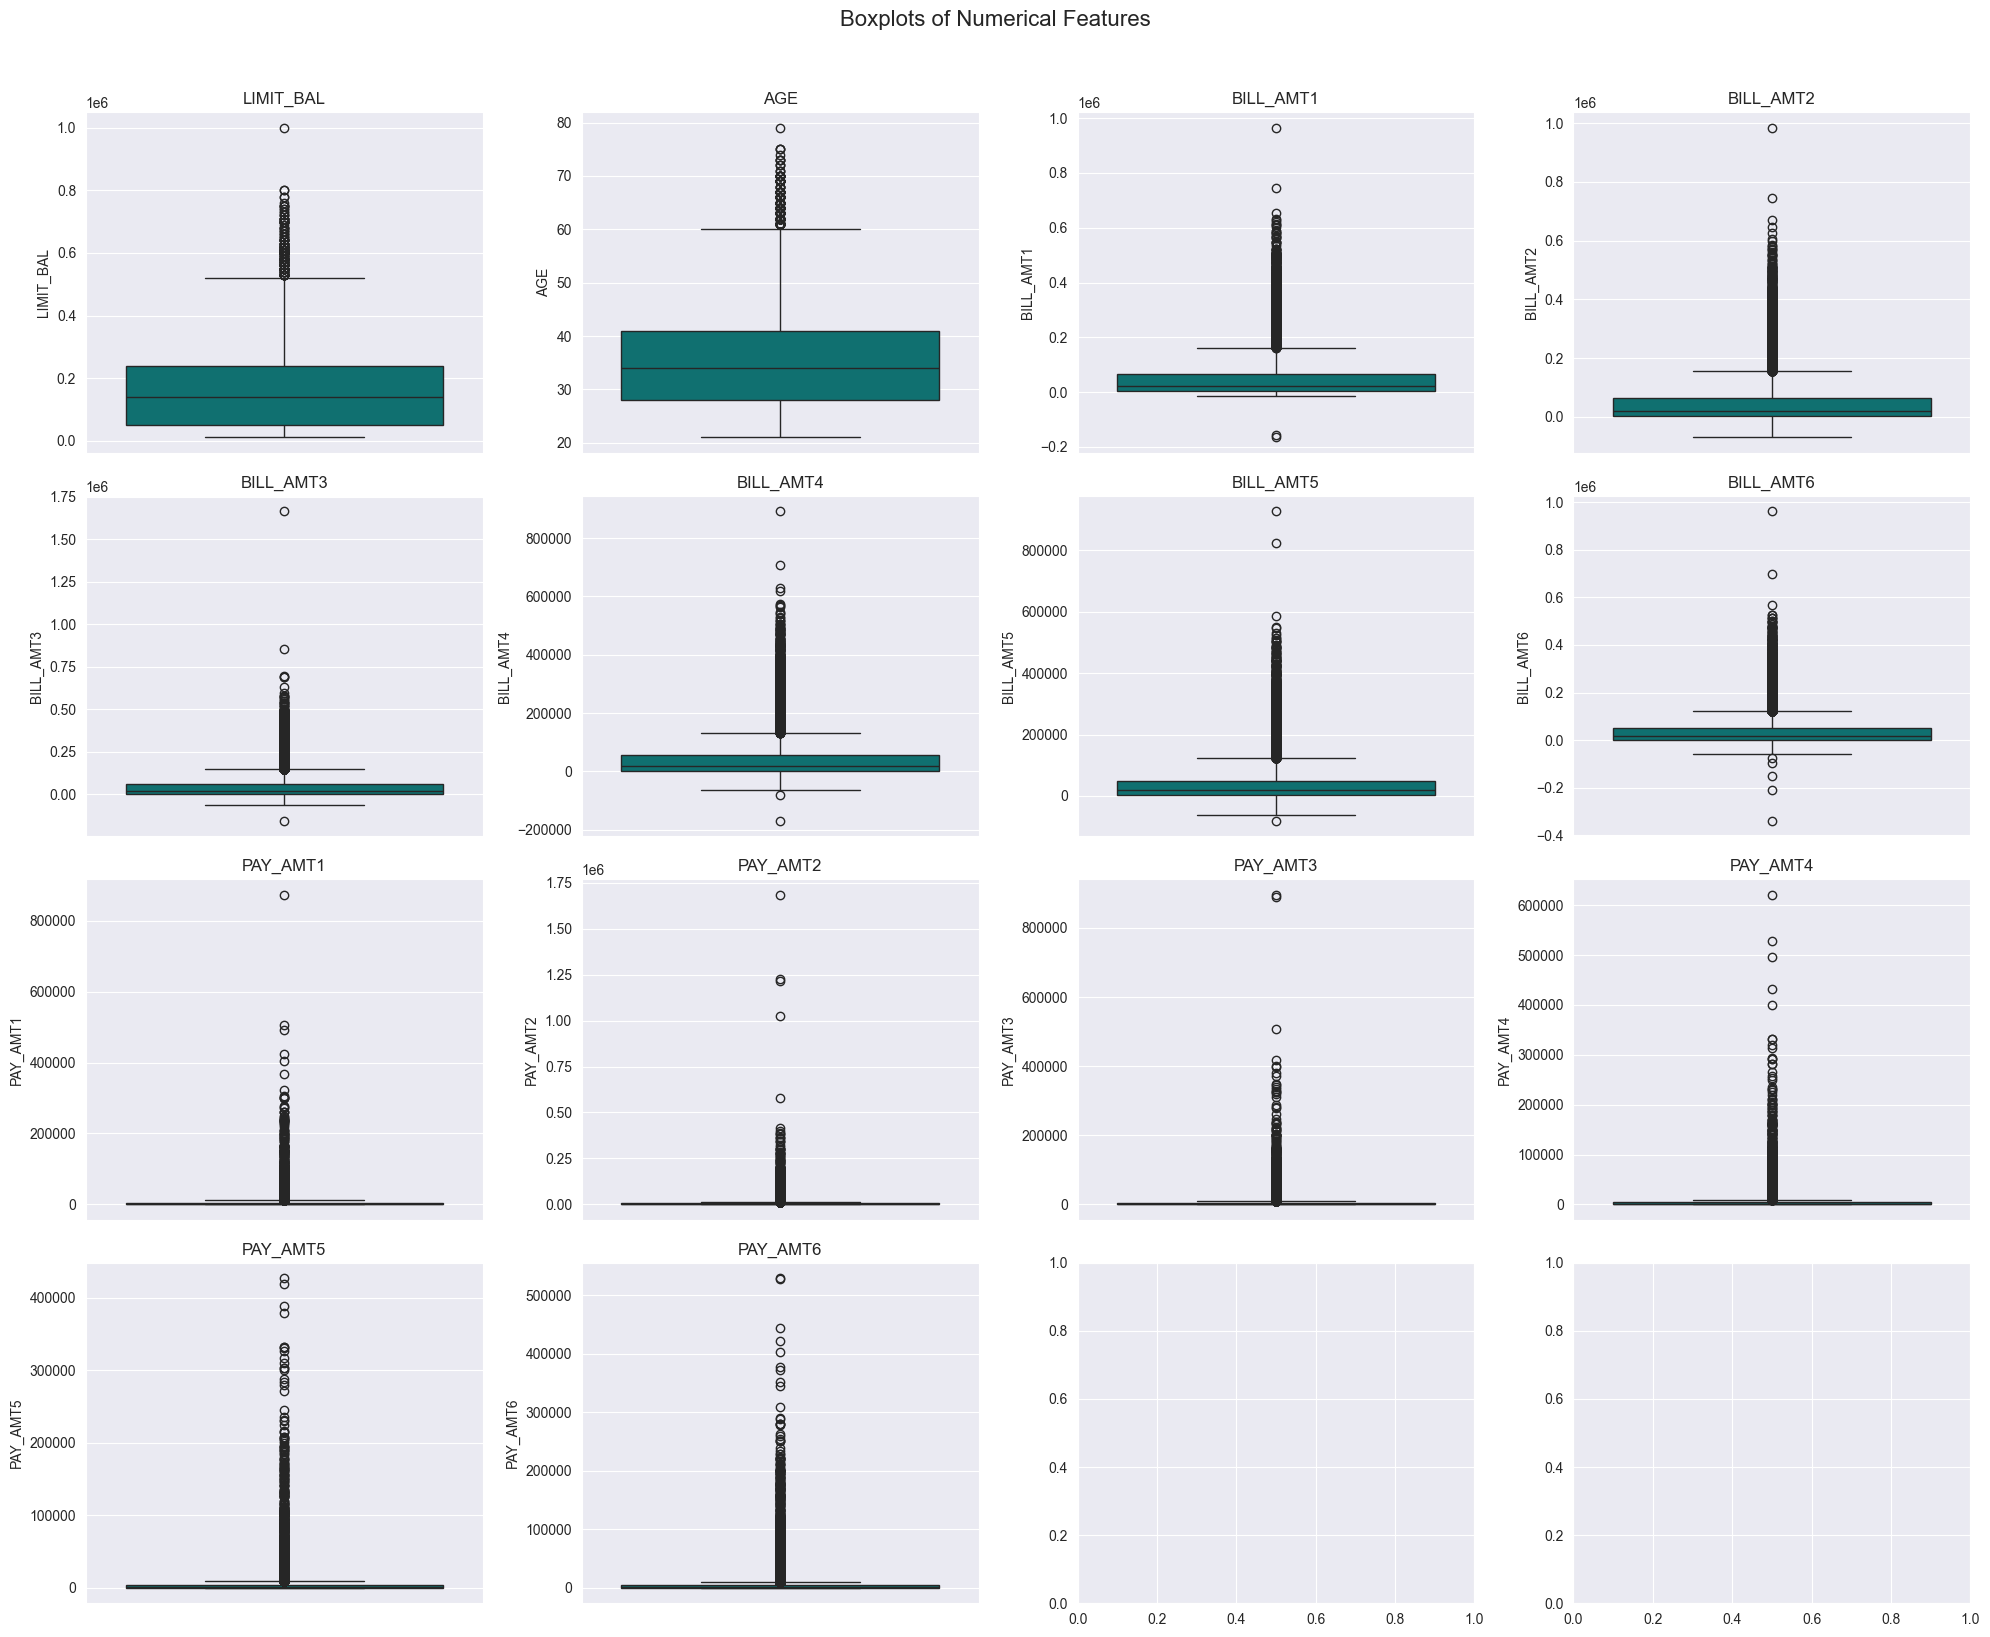

In [64]:
# Boxplots to check outliers
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, j in enumerate(num_cols):
    sns.boxplot(y=df[j], ax=axes[i], color='teal')
    axes[i].set_title(j)
    axes[i].set_xlabel('')

# Hide any unused subplots
for idx in range(len(num_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots of Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

* Outliers are present in every single feature — but this is expected in financial data and are real values.
* Yeo-Johnson transformation seems to be a good choice as it addresses both skewness and compresses outliers simultaneously

### Bivariate Analysis

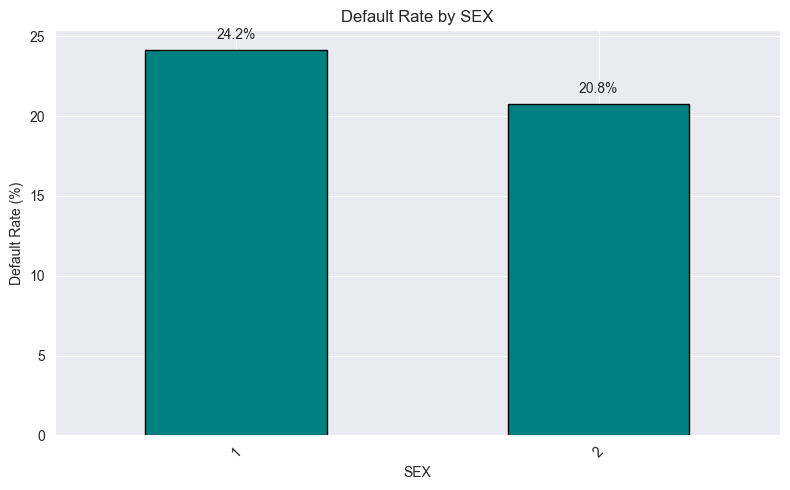

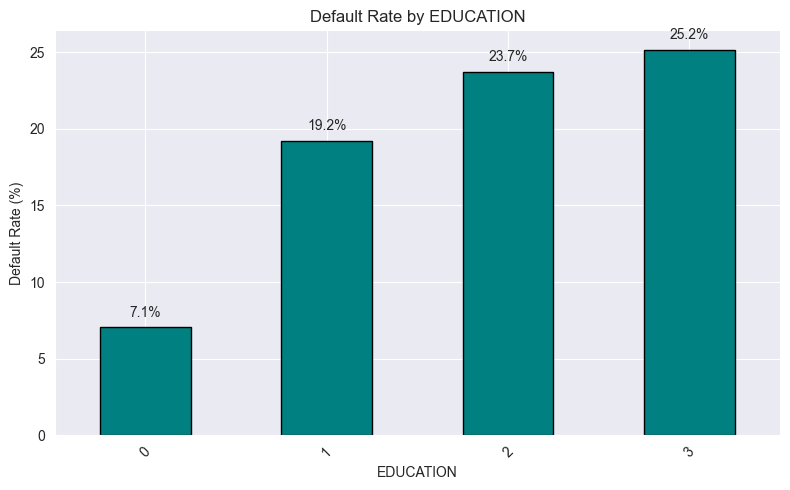

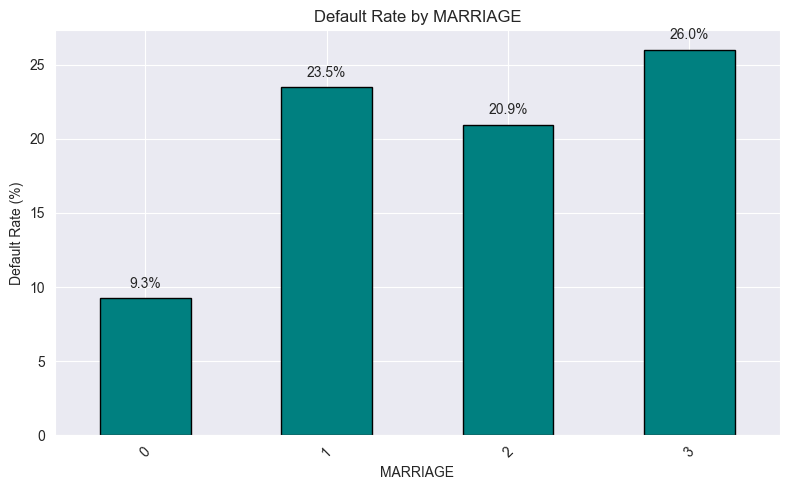

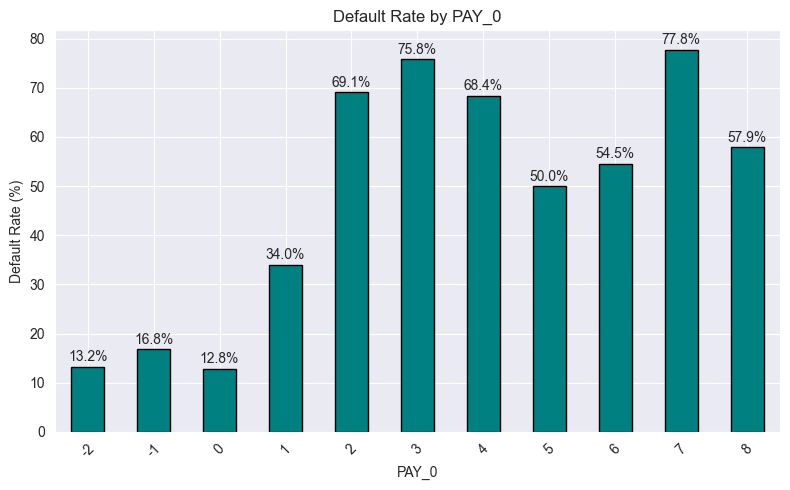

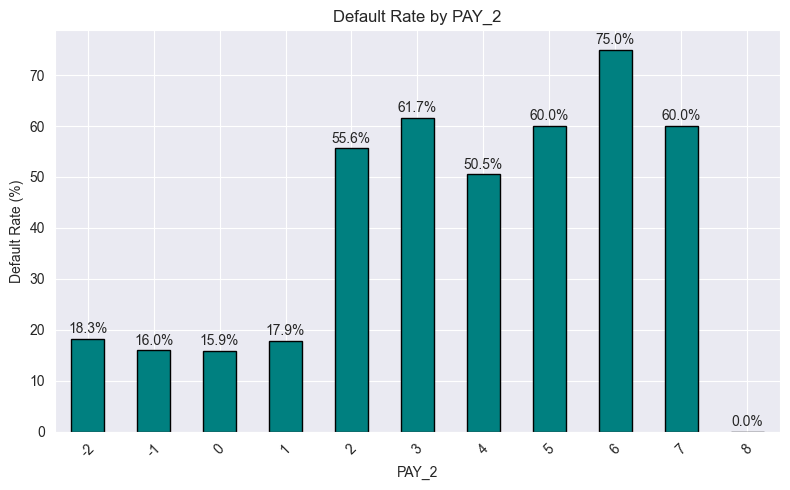

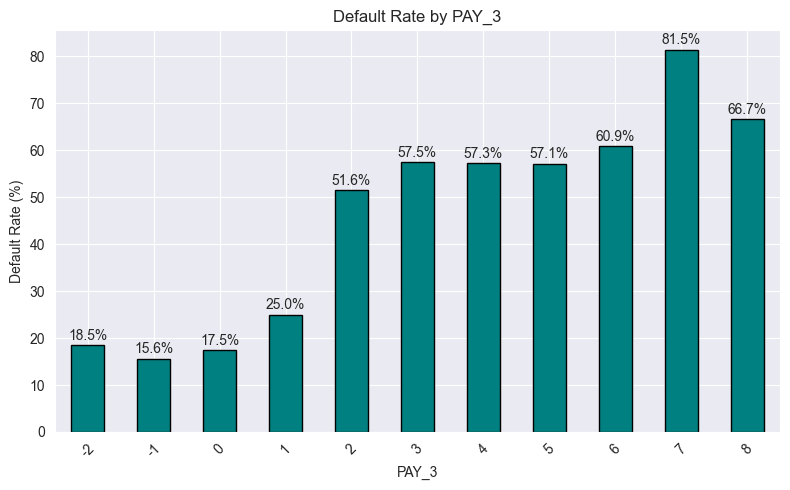

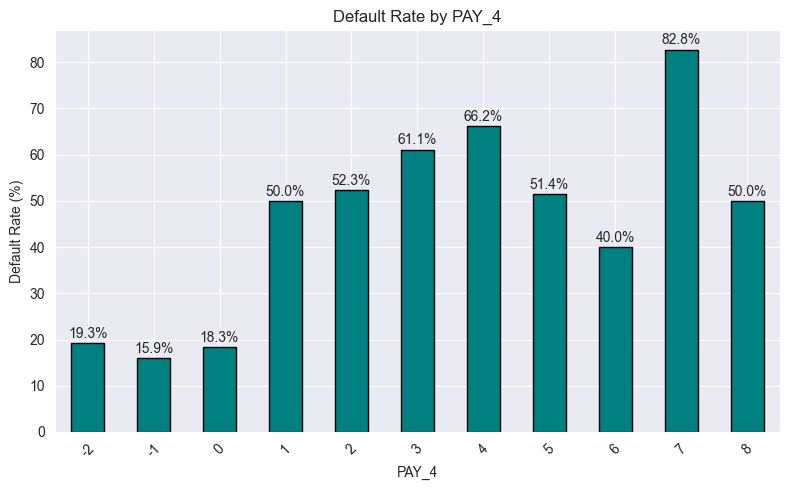

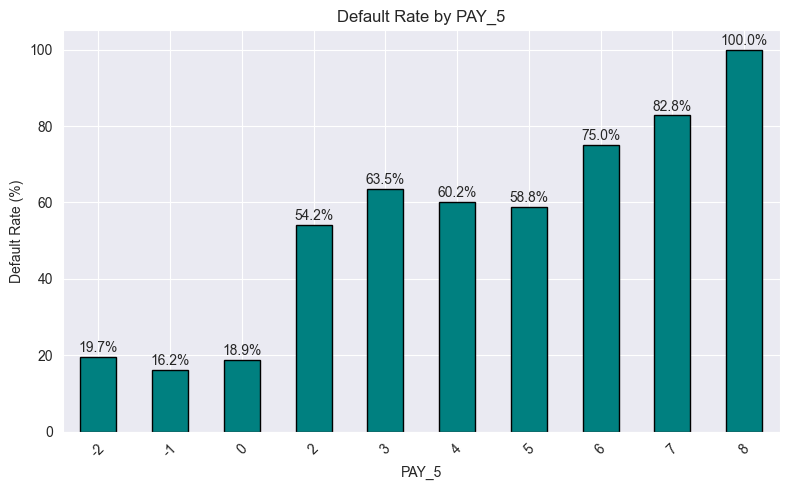

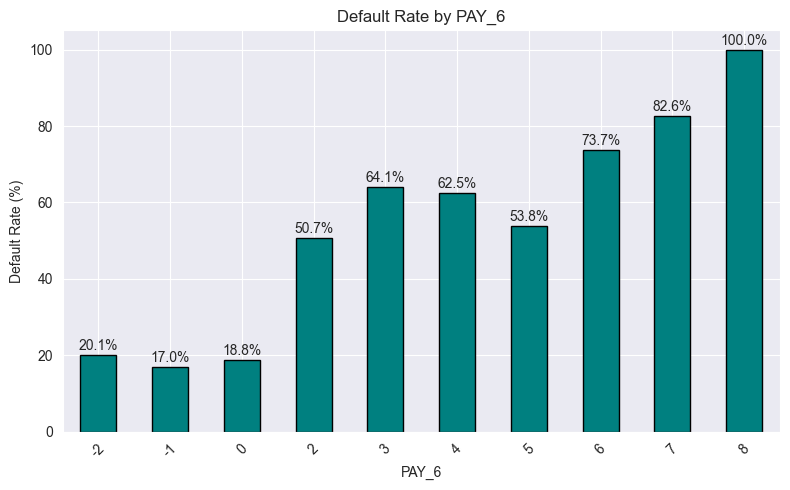

In [72]:
for col in cat_features:
    plt.figure(figsize=(8, 5))

    default_rate = (cat_cols.groupby(col)['default.payment.next.month']
                    .apply(lambda x: x.astype(int).mean()) * 100)

    ax = default_rate.plot(kind='bar', color='teal', edgecolor='black')

    # Add percentage labels on top of each bar
    for i, v in enumerate(default_rate):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

    plt.title(f'Default Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

MARRIAGE and SEX seem to have low predictive power.

#### Education
* Bivariate analysis reveals a clear trend between education level and default rate — customers with lower education levels tend to default more frequently. High school graduates have the highest default rate (25.2%), followed by university graduates (23.7%) and graduate school graduates (19.2%). The unknown/others category (0) shows a notably low default rate of 7.1%, however this should be interpreted with caution as it represents only 1.6% of the dataset (~468 rows), making this estimate less statistically reliable.

#### PAY_0 - PAY_6
The PAY columns show the strongest and most consistent relationship with the target variable of any feature
in the dataset. There is a dramatic jump in default rate between the "no delay" categories and the delay categories:

- **-2, -1, 0** (no consumption, paid in full, revolving credit): default rates range from **12–20%**
- **1** (1 month delay): default rates jump to **25–50%**
- **2+** (2+ months delay): default rates rise sharply to **50–80%+**

**PAY_0** (September 2005, the most recent month) shows the sharpest and most pronounced jump, suggesting
that more recent payment behaviour is more predictive of default than older payment history.

Notable caveats:
- The 100% default rates observed for value 8 in PAY_5 and PAY_6 are unreliable, as these categories
  contain only 1–3 rows
- Similarly, the 0.0% default rate for value 8 in PAY_2 is based on a single row and should not be
  interpreted as meaningful

##### Binning Decision
Based on the bivariate analysis, the following binning strategy is applied to all PAY columns:

| Original Values | New Value | Rationale |
|---|---|---|
| -2 | -2 | Kept separate — distinct behaviour, sufficient data |
| -1 | -1 | Kept separate — distinct behaviour, sufficient data |
| 0 | 0 | Kept separate — most common category, distinct behaviour |
| 1, 2 | 2 | Merged — value 1 is extremely sparse and shows inconsistent default rates across columns |
| 3, 4, 5, 6, 7, 8 | 3 | Merged — all show similarly high default rates (50–80%+) and are individually too sparse to be reliable |

This binning strategy is justified on two grounds: statistical sparsity of the higher delay categories,
and the similar default rates observed across values 3–8 in the bivariate analysis.


ValueError: The palette dictionary is missing keys: {'0', '1'}

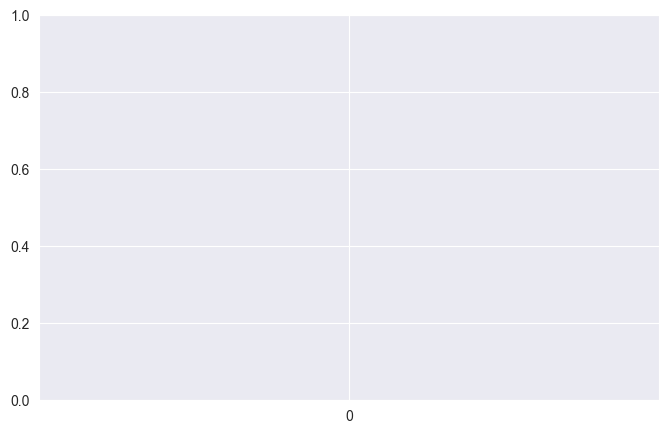

In [75]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.violinplot(x='default.payment.next.month', y=col, data=df, palette={0: 'teal', 1: 'coral'}, inner='box')

    plt.title(f'{col} by Default Payment')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

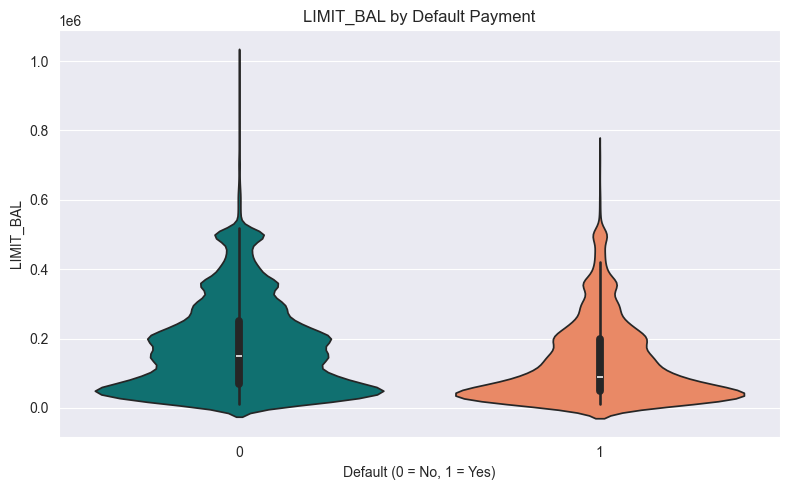

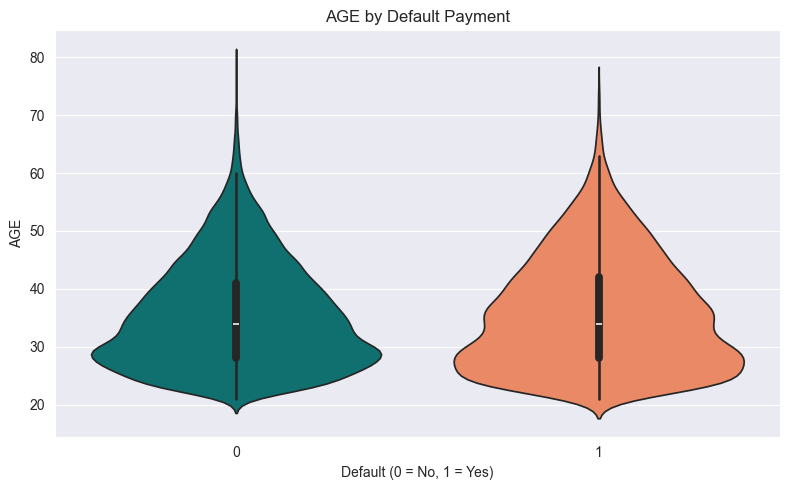

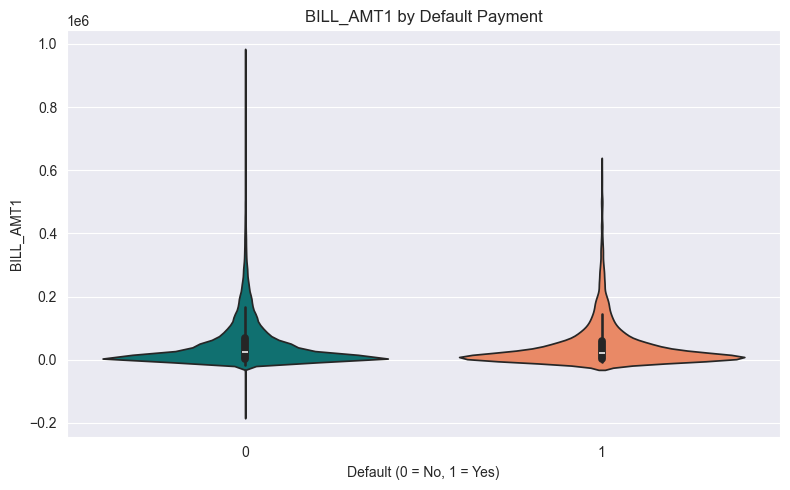

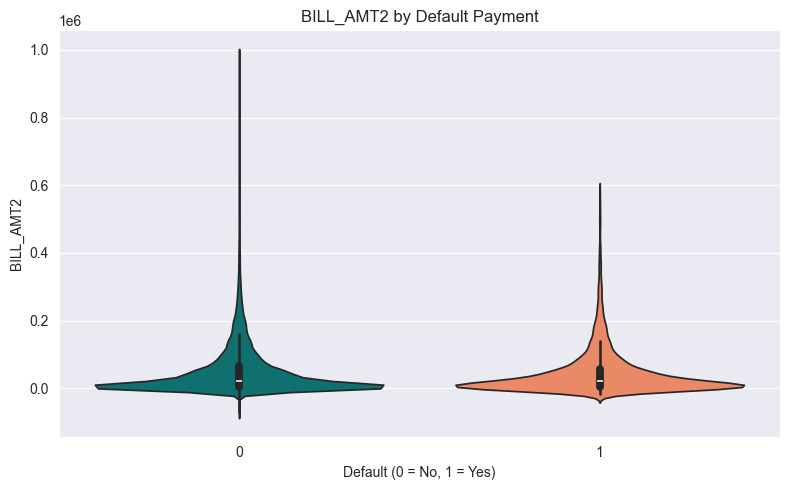

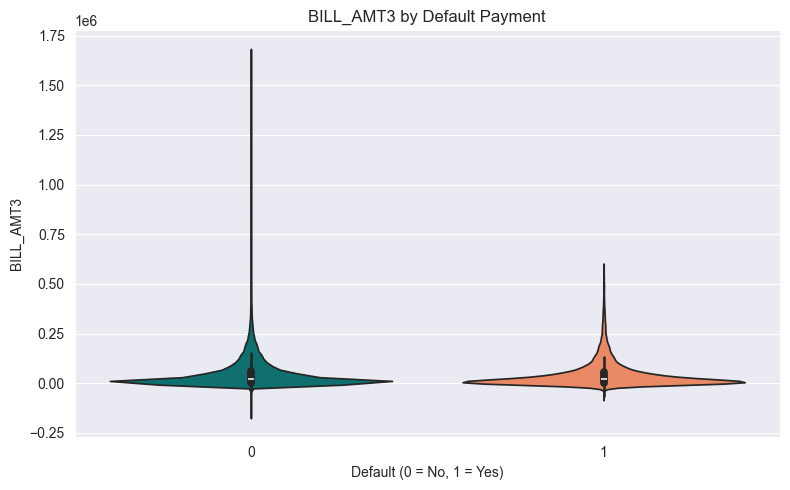

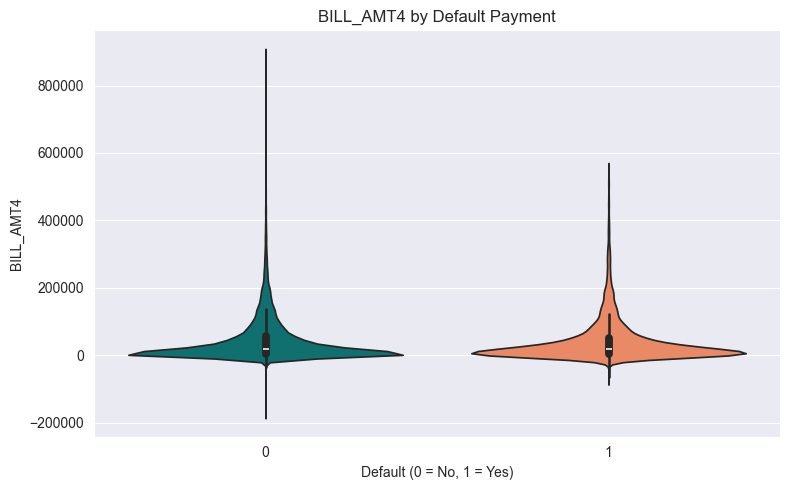

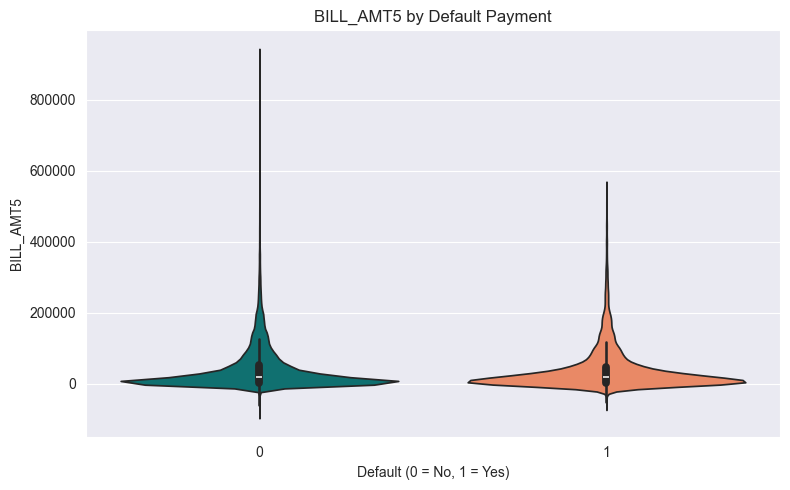

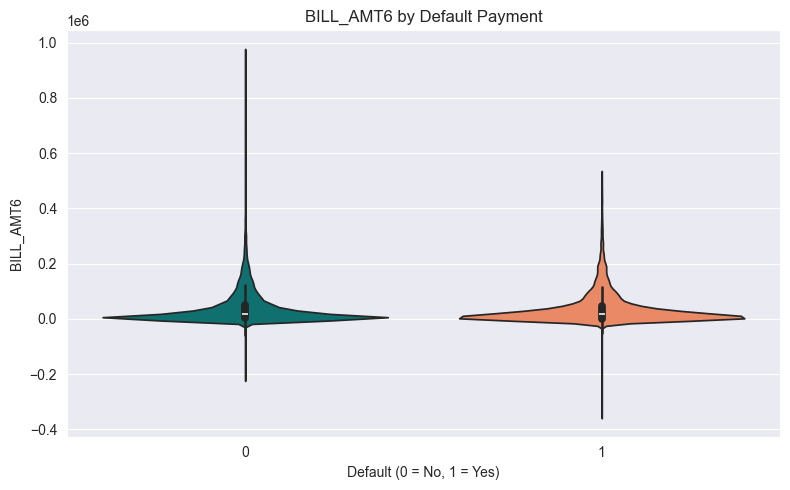

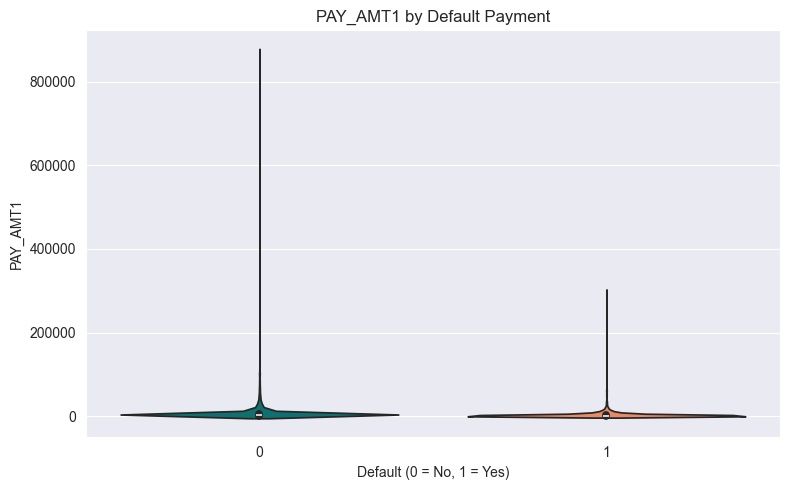

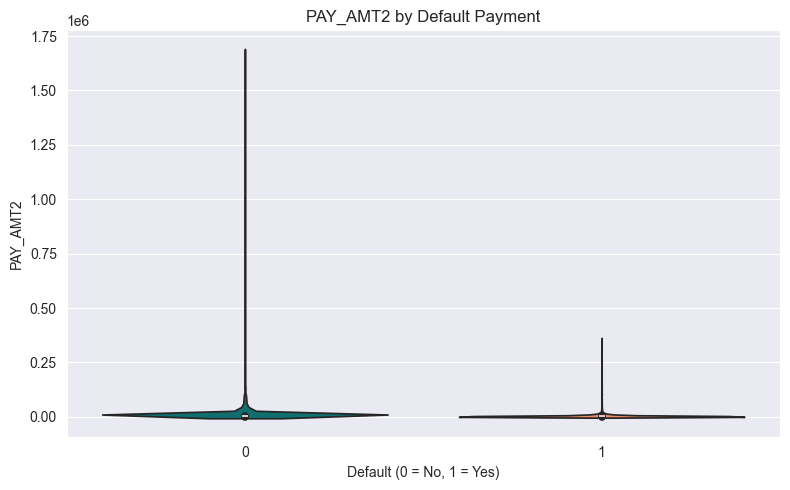

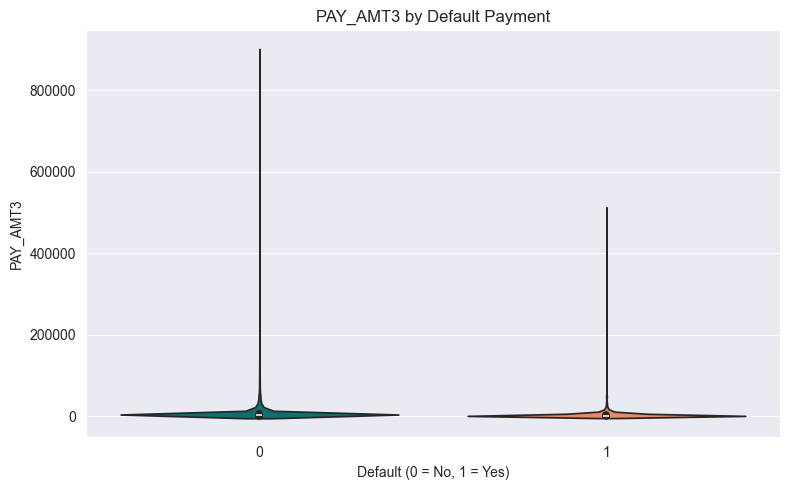

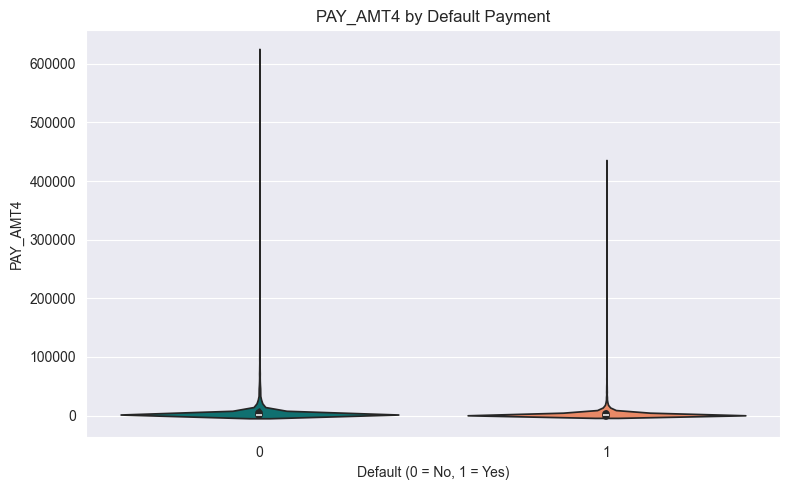

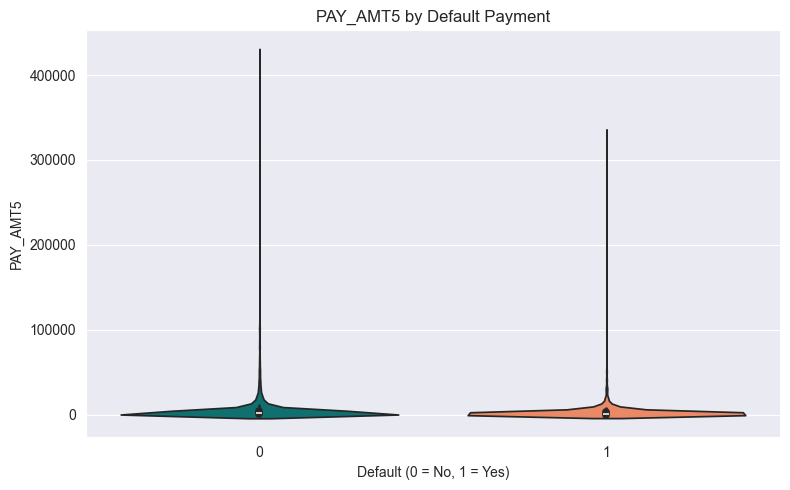

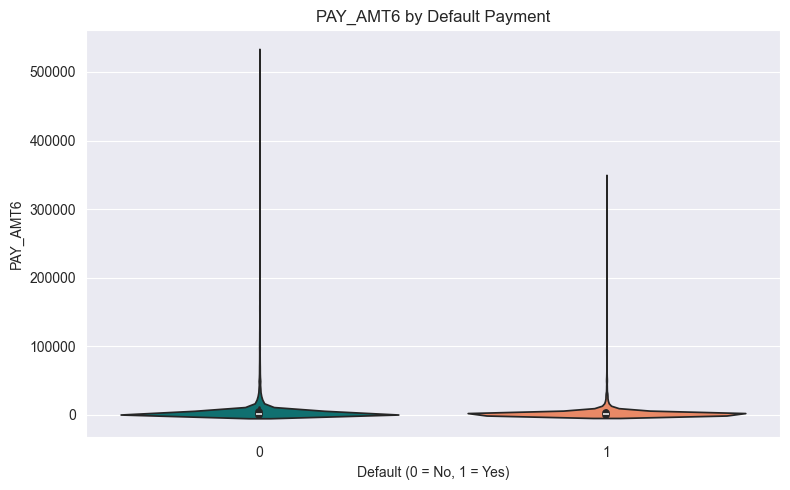

In [76]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.violinplot(x='default.payment.next.month', y=col, data=df,
                   palette={'0': 'teal', '1': 'coral'},
                   inner='box')

    plt.title(f'{col} by Default Payment')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

ValueError: The palette dictionary is missing keys: {'0', '1'}

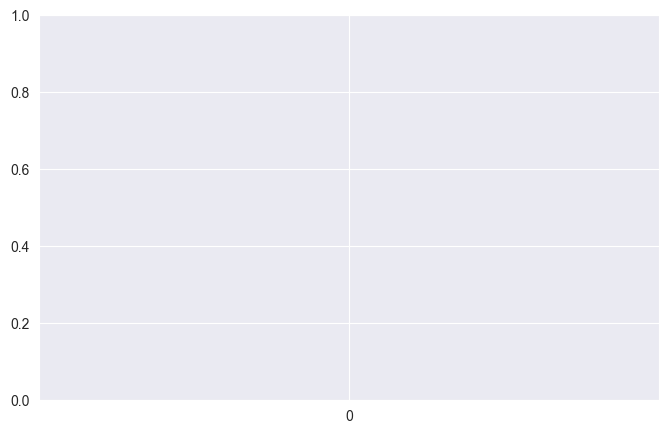

In [77]:
# Sample a subset just for the strip plot
df_sample = df.sample(n=500, random_state=42)

for col in num_cols:
    plt.figure(figsize=(8, 5))

    # Violin plot on full data
    sns.violinplot(x='default.payment.next.month', y=col, data=df,
                   palette={0: 'teal', 1: 'coral'},
                   inner=None)  # inner=None because strip plot will show the points

    # Strip plot on sampled data
    sns.stripplot(x='default.payment.next.month', y=col, data=df_sample,
                  color='black', alpha=0.3, size=3, jitter=True)

    plt.title(f'{col} by Default Payment')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

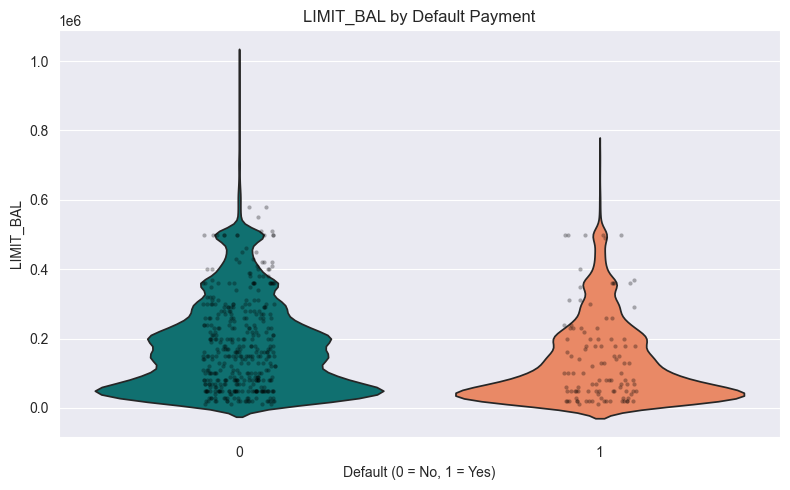

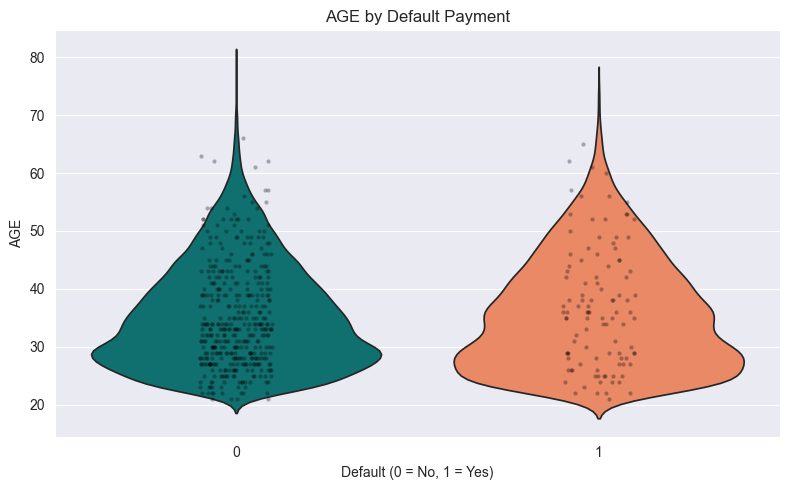

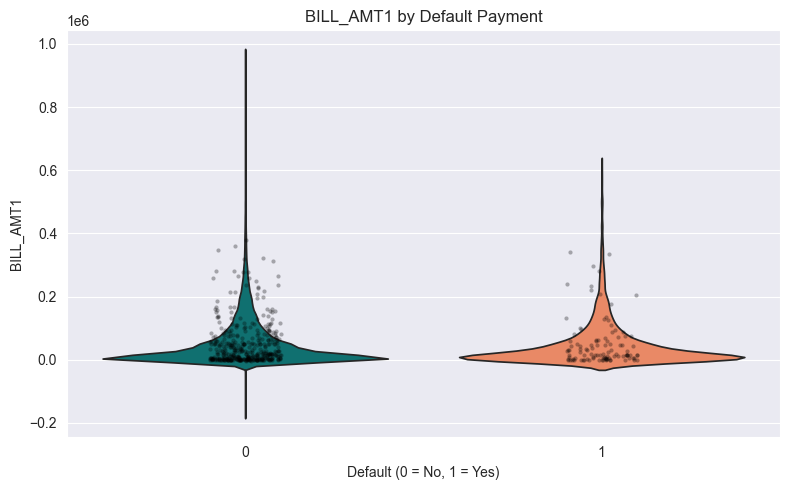

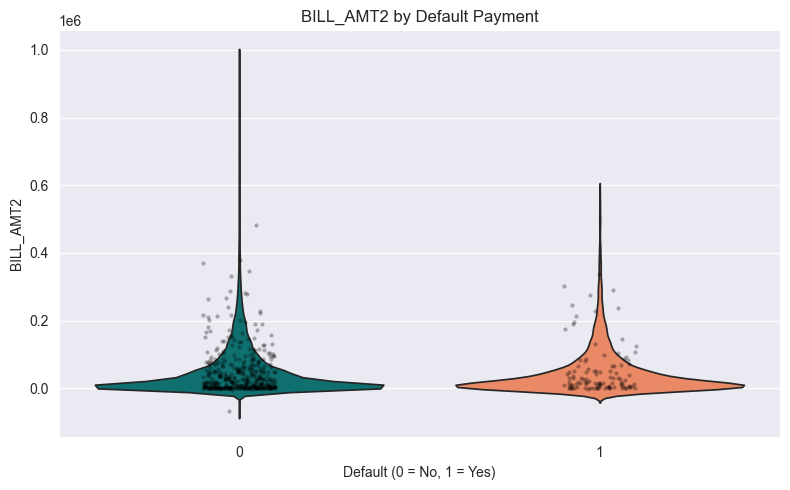

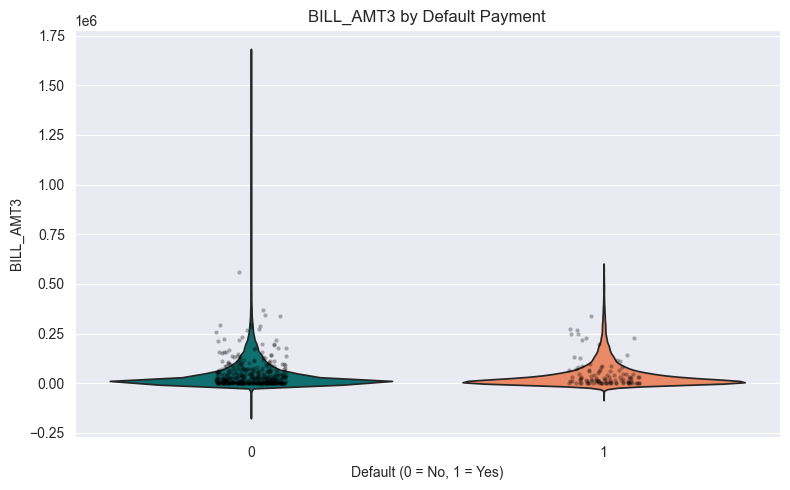

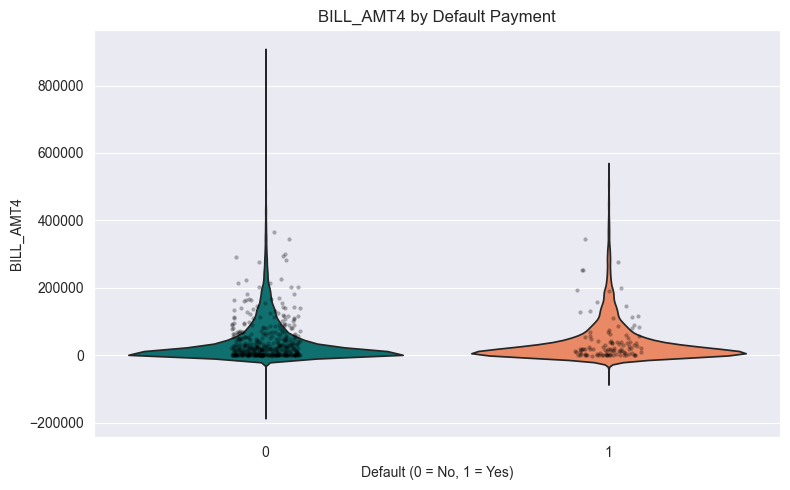

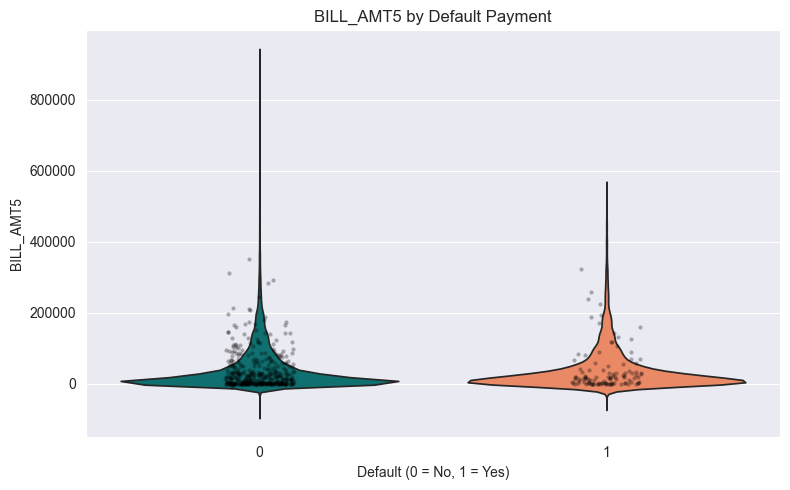

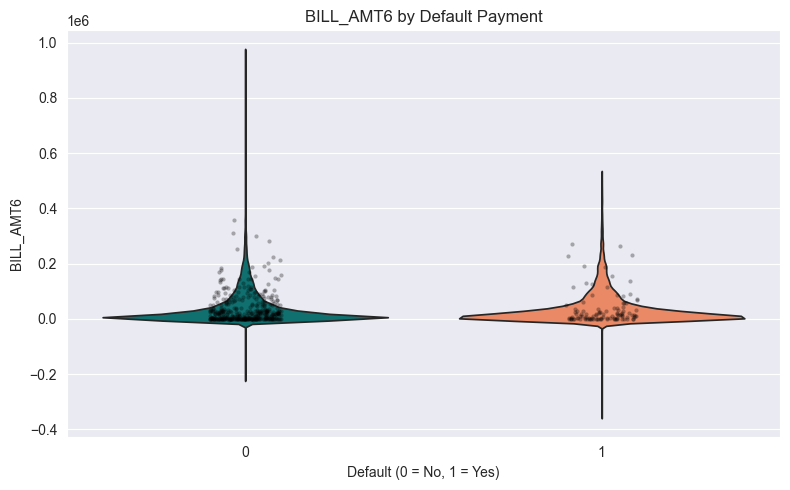

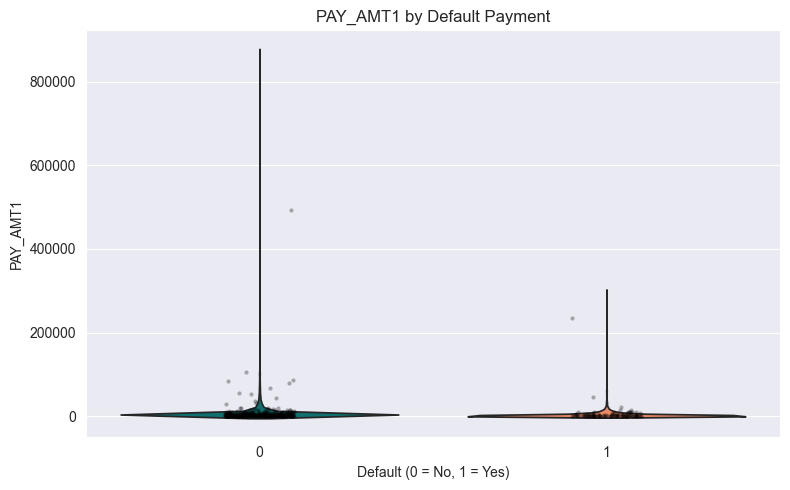

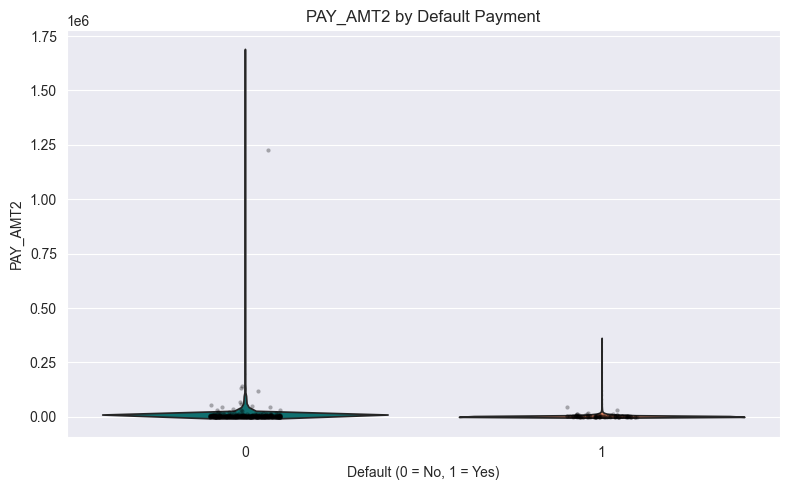

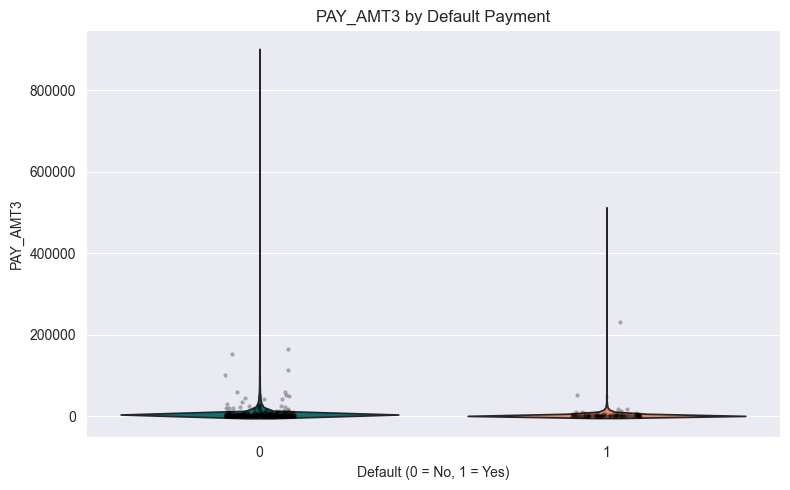

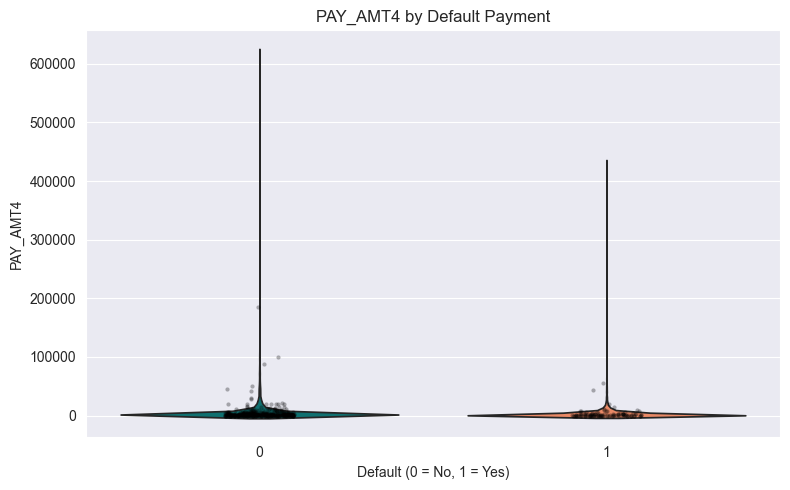

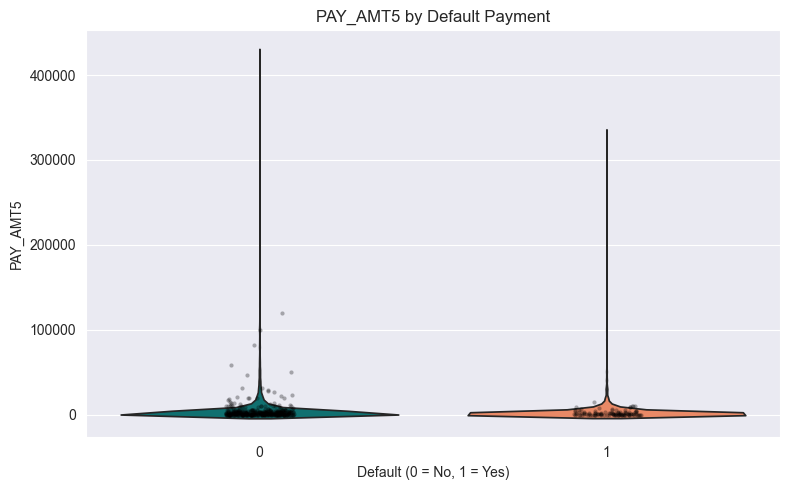

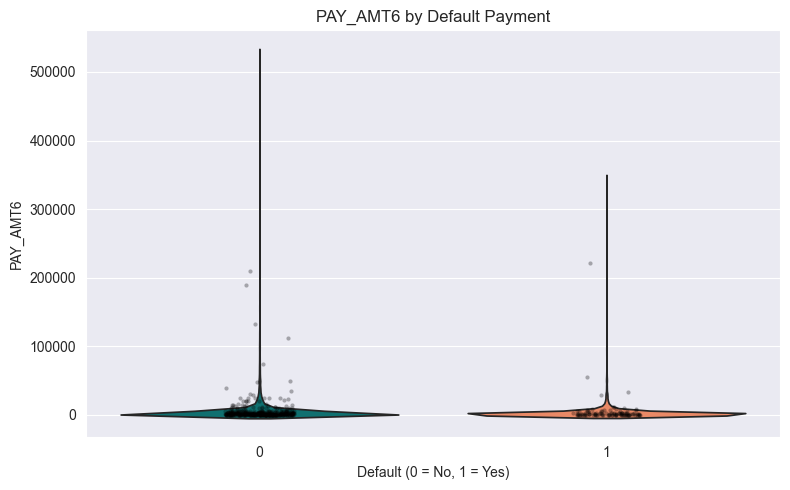

In [79]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.violinplot(x='default.payment.next.month', y=col, data=df,
                   palette=['teal', 'coral'],  # list instead of dict
                   inner=None)

    sns.stripplot(x='default.payment.next.month', y=col, data=df_sample,
                  color='black', alpha=0.3, size=3, jitter=True)

    plt.title(f'{col} by Default Payment')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

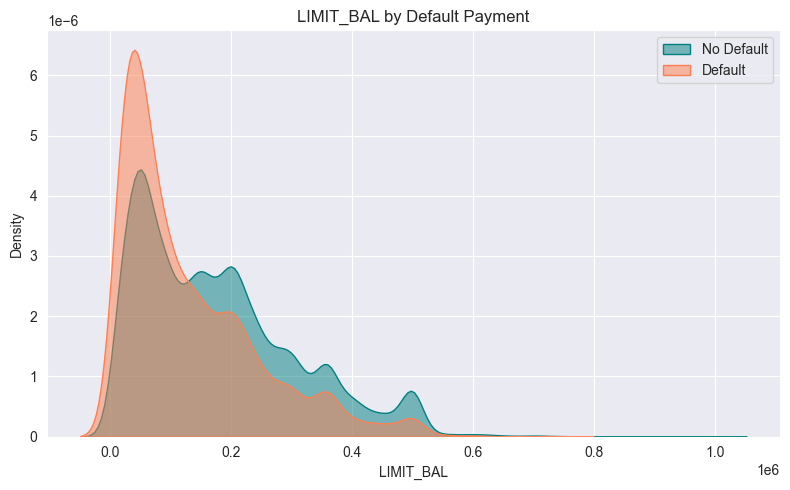

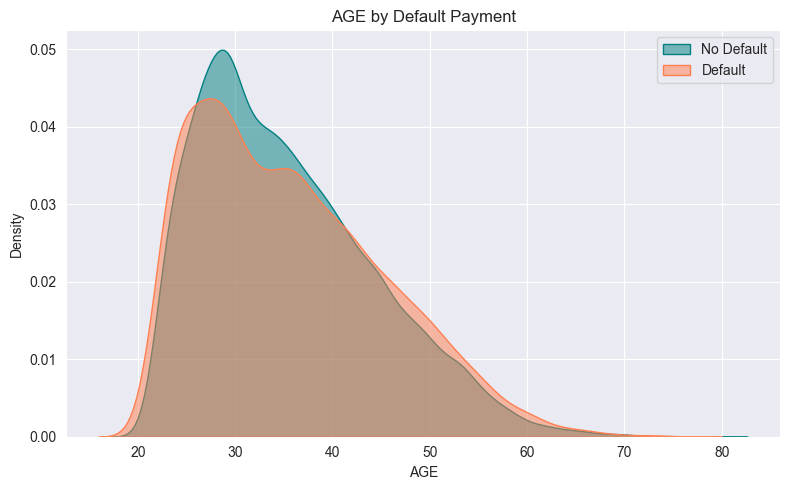

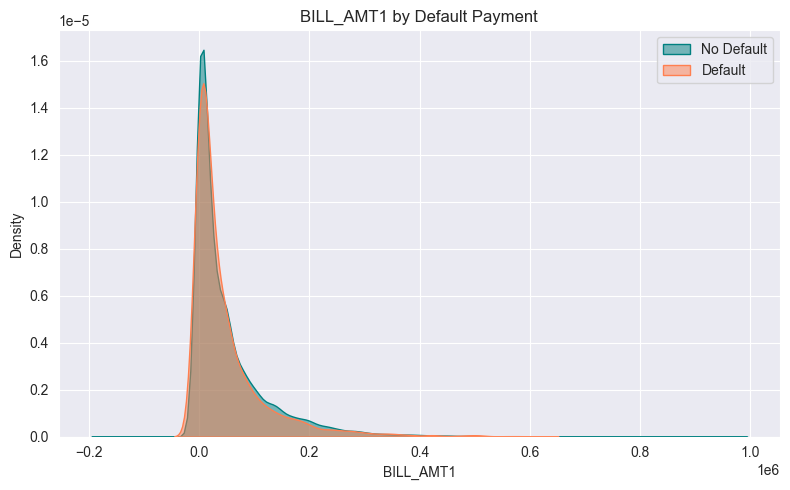

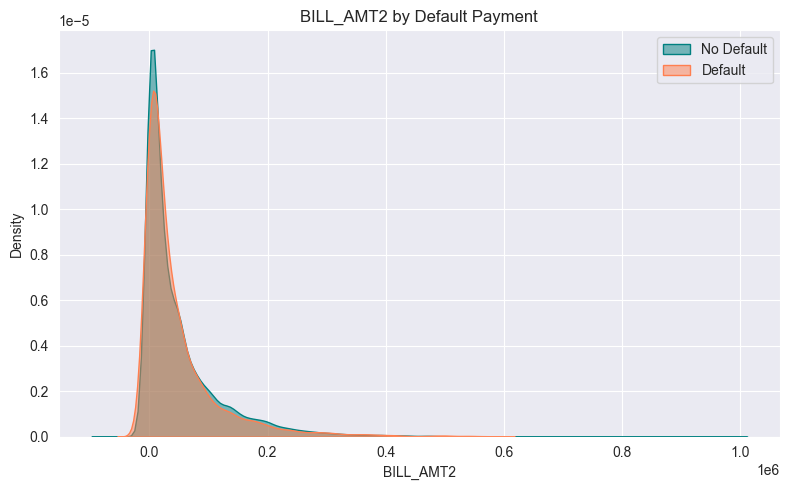

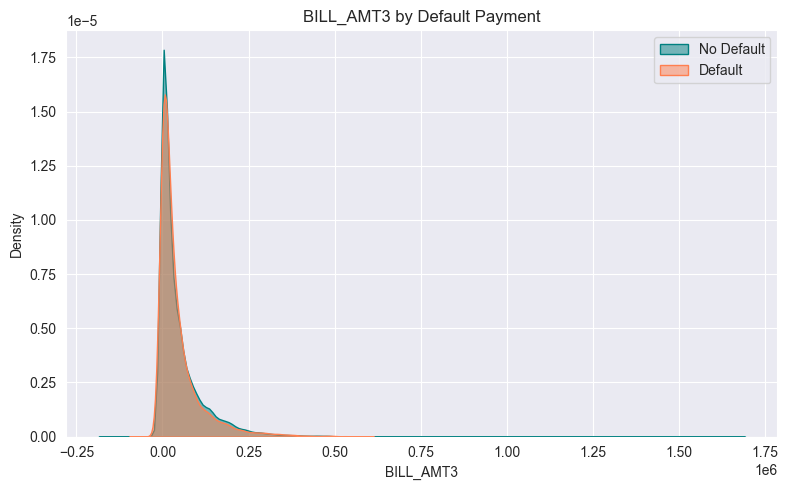

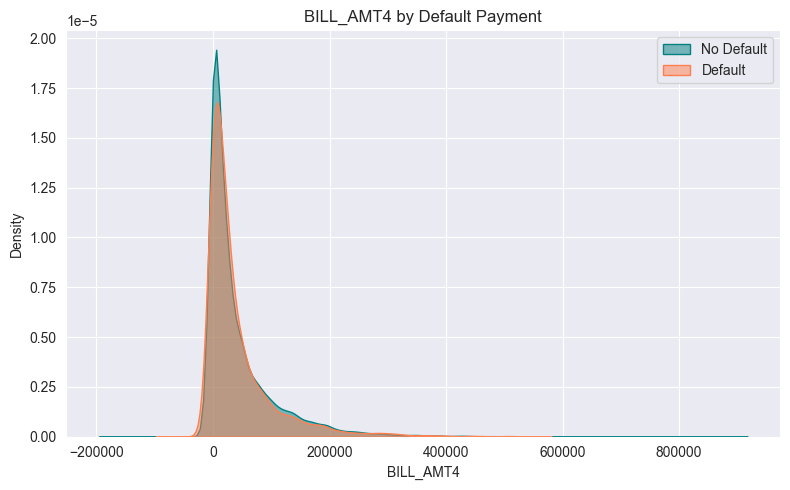

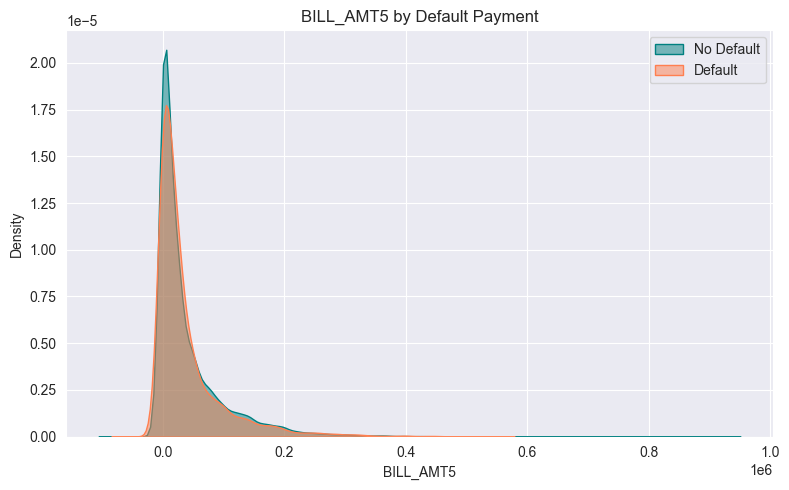

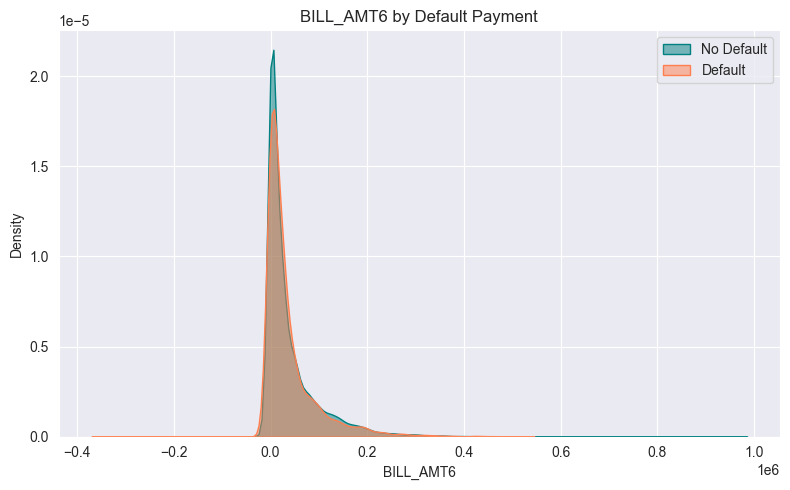

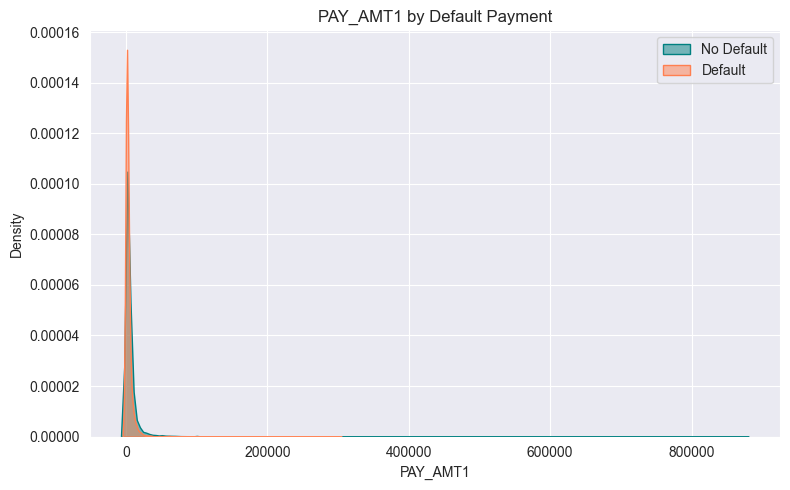

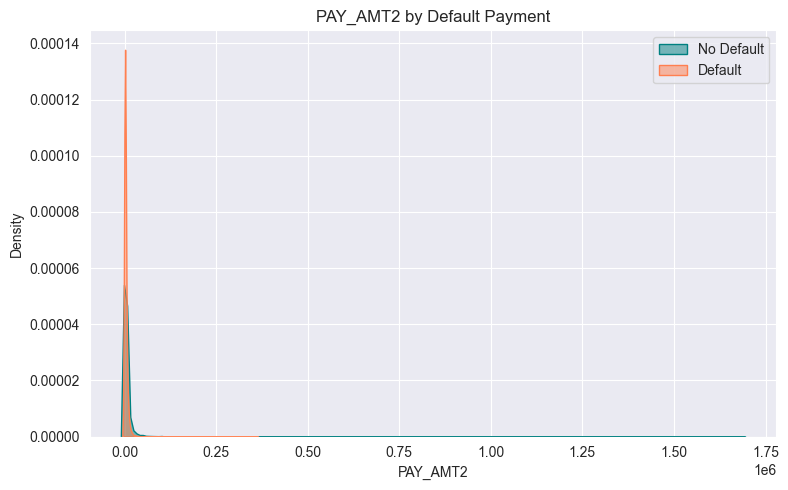

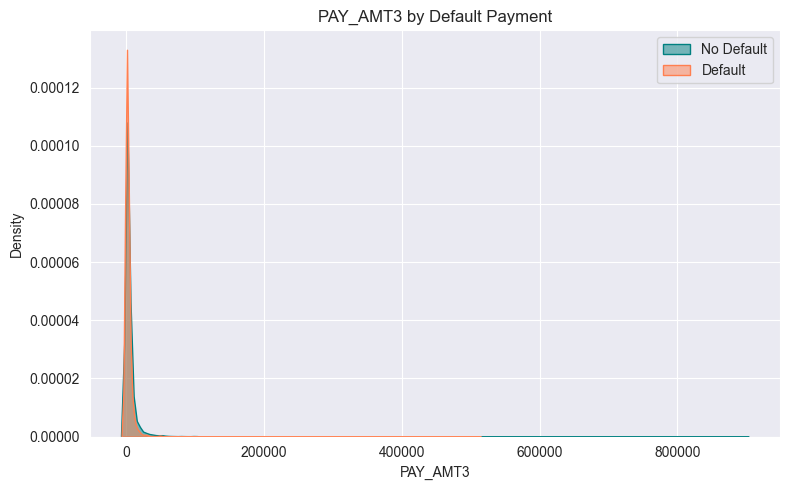

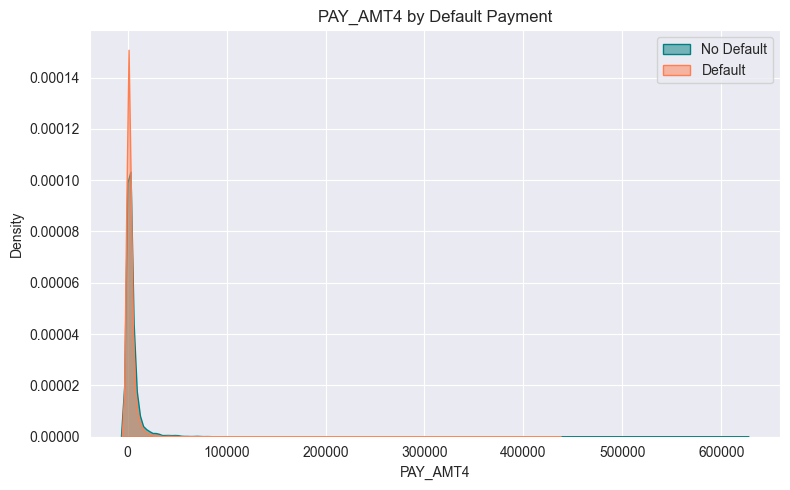

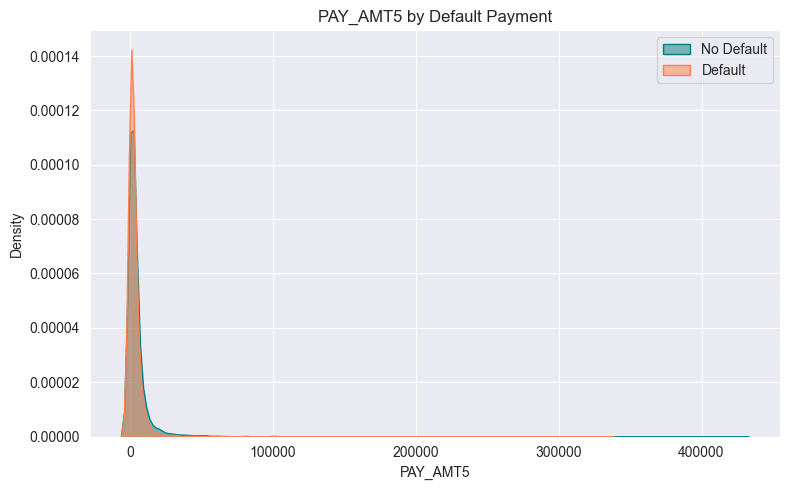

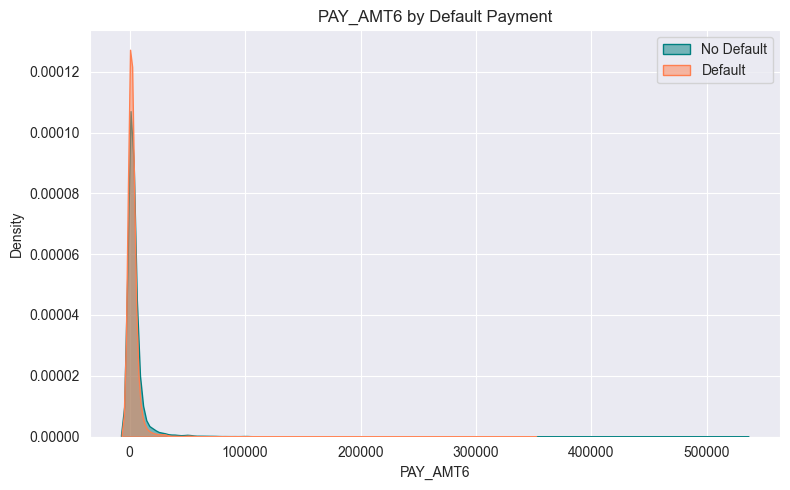

In [80]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    for target, color, label in zip([0, 1], ['teal', 'coral'], ['No Default', 'Default']):
        sns.kdeplot(df[df['default.payment.next.month'] == target][col],
                    fill=True, color=color, label=label, alpha=0.5)

    plt.title(f'{col} by Default Payment')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

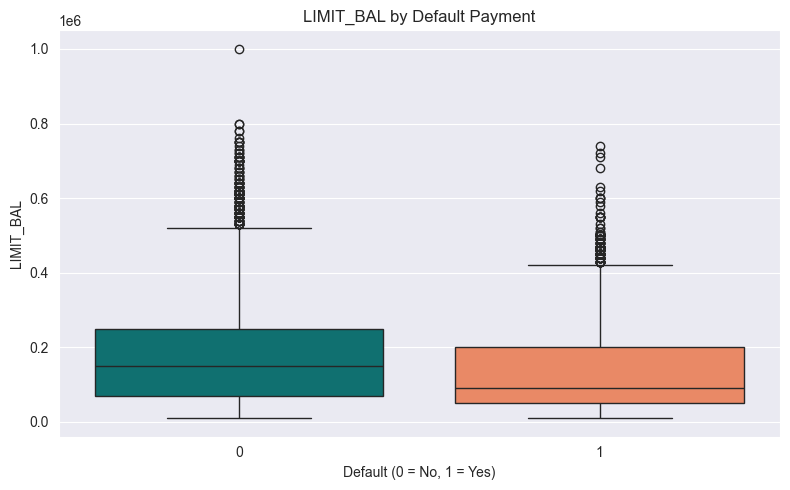

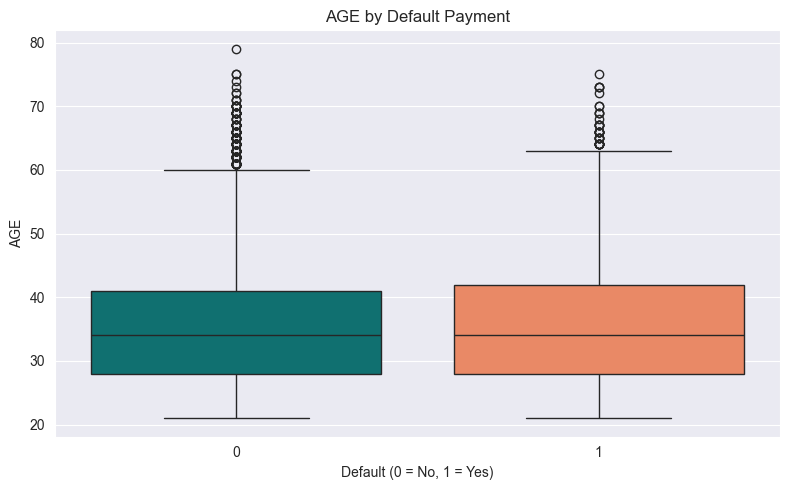

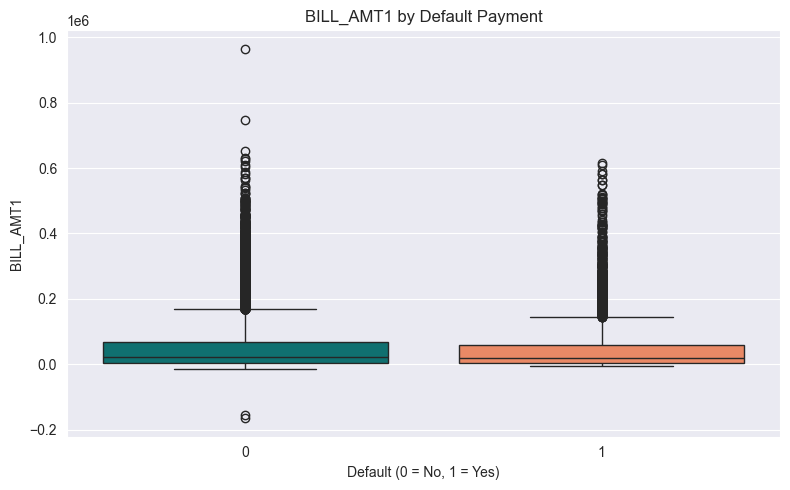

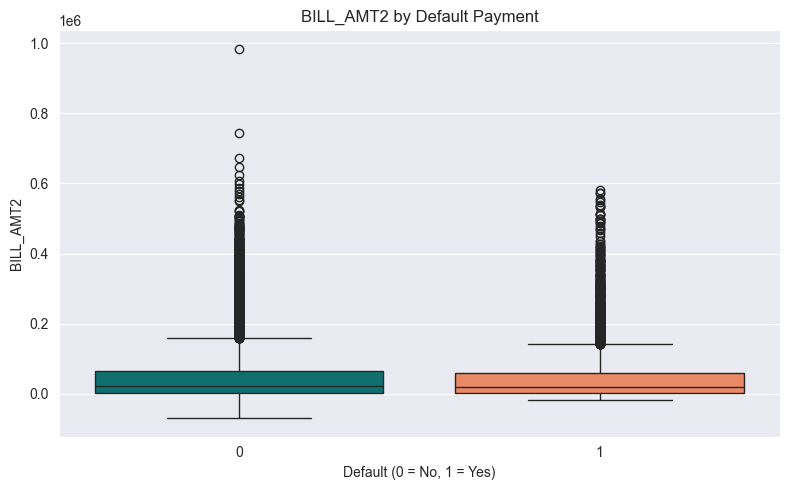

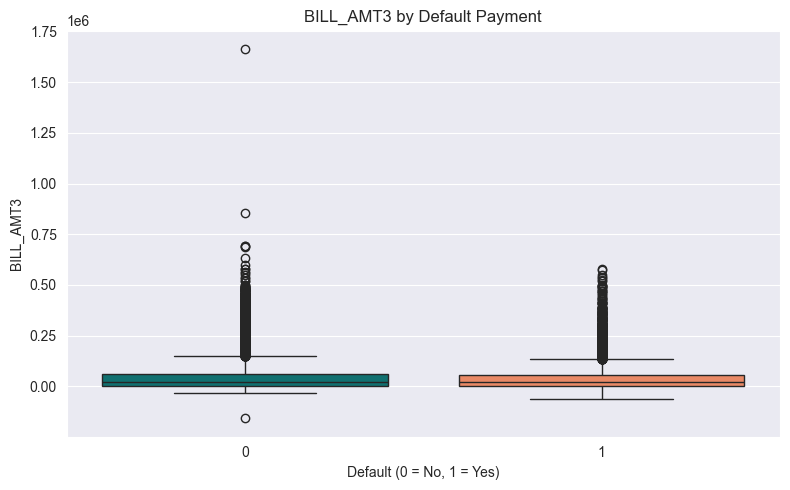

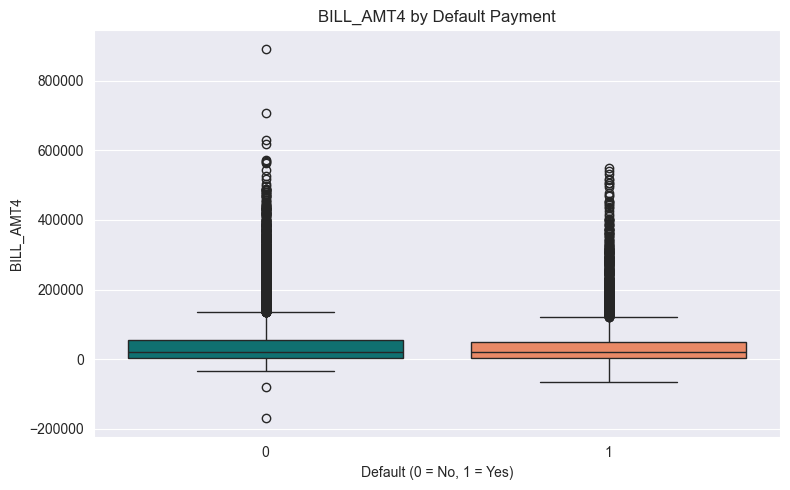

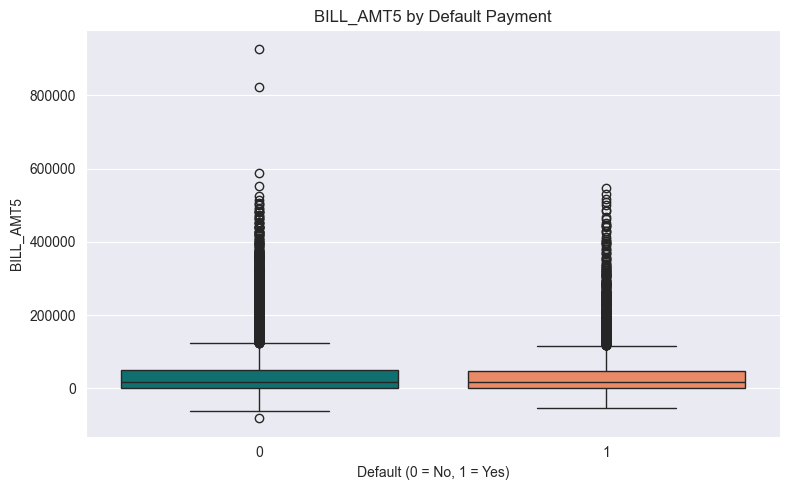

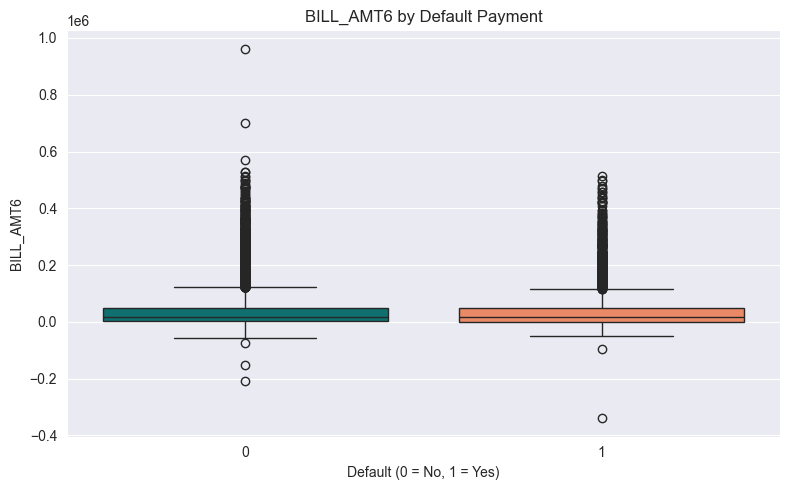

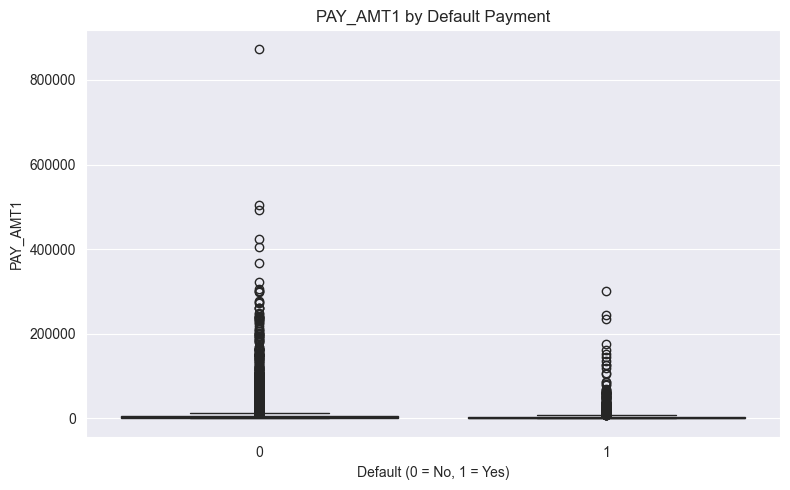

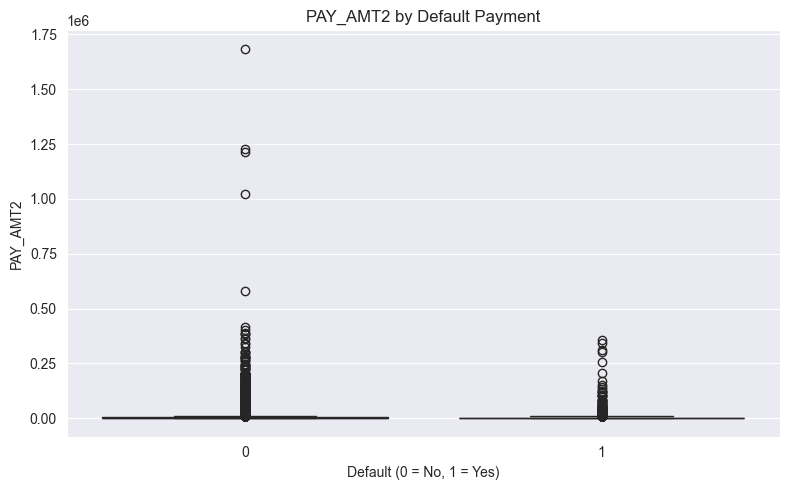

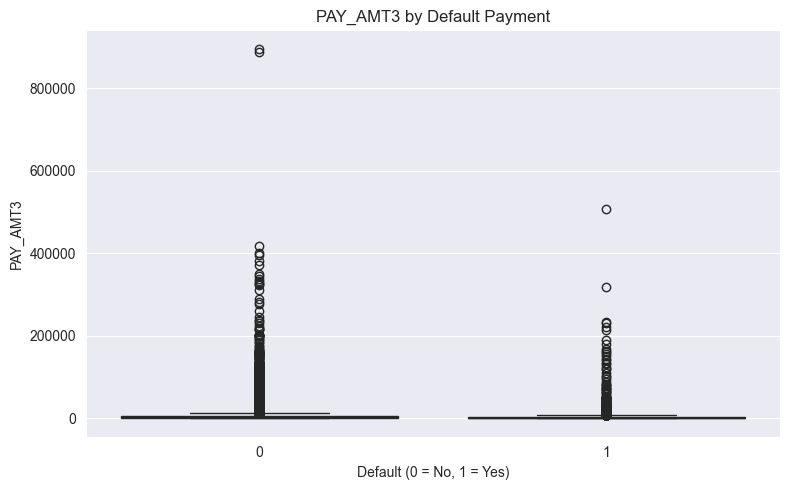

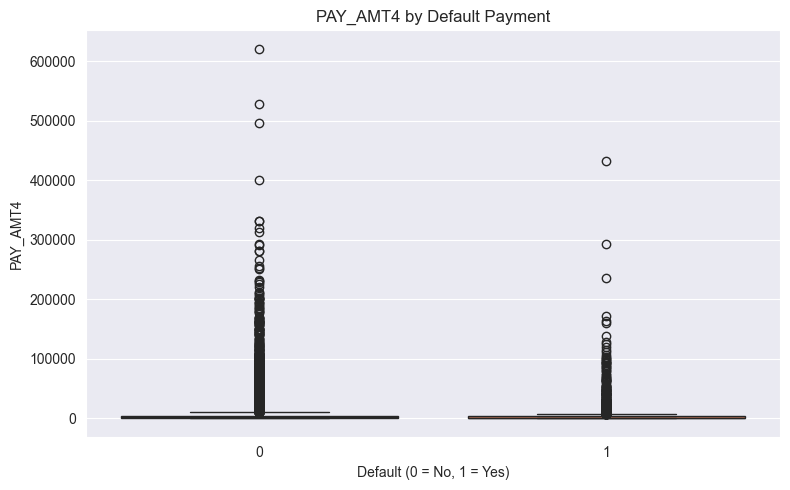

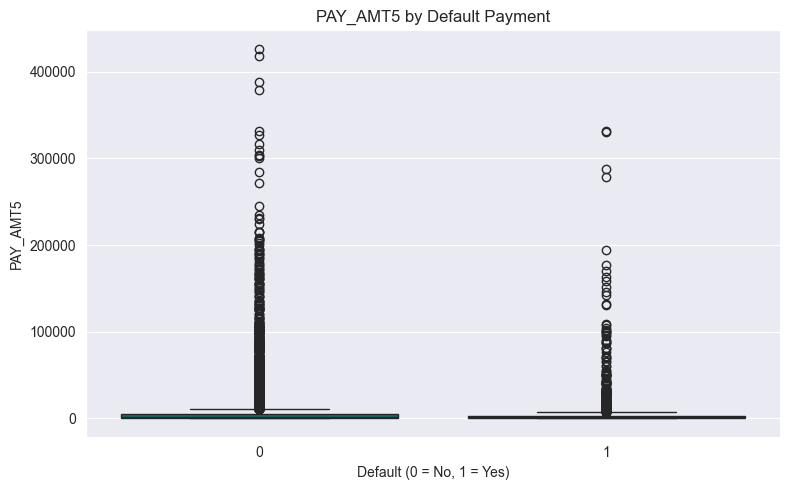

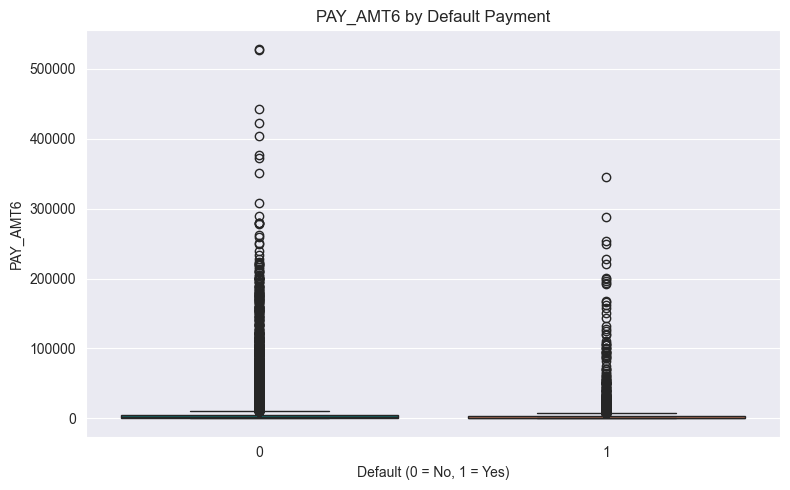

In [81]:
for col in num_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(x='default.payment.next.month', y=col, data=df,
                palette=['teal', 'coral'])

    plt.title(f'{col} by Default Payment')
    plt.xlabel('Default (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()